<a href="https://colab.research.google.com/github/swilli21/GenAI/blob/master/Autoencoder_FashionMNIST_DNN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train an AutoEncoder using a Dense Neural network


- A dense neural network (or fully connected network) is a machine learning model where every neuron in one layer connects to every neuron in the next, allowing it to learn complex non-linear mappings.





In [1]:
import torch.nn as nn
import torchvision
import numpy as np

import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm #use to display progress bars
from torchvision import datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, random_split

In [2]:
import torch

In [3]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

PyTorch tensors are multi-dimensional arrays that can be stored and trained on GPUs

In [4]:
train_data = datasets.FashionMNIST( #labels class or category associated with each image
    '/content/data', #directory for dataset
    transform = transforms.ToTensor(), # convert all the images in the data to PyTorch tensors
    download = True,
    train = True # this is defaulted as True if not specified
)

test_data = datasets.FashionMNIST(
    '/content/data',
    transform = transforms.ToTensor(),
    download = True,
    train = False # this is defaulted as True if not specified
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 6.84MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 130kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.39MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.0MB/s]


In [5]:
len(train_data)

60000

In [6]:
len(test_data)

10000

### Data split into training, validation, and test set

In [7]:
train_data, valid_data = random_split(train_data, [50000, 10000])

train_dl = DataLoader(train_data, batch_size = 128, shuffle = True)
valid_dl = DataLoader(valid_data, batch_size = 128, shuffle = False)
test_dl = DataLoader(test_data, batch_size = 128, shuffle = False)

len(train_dl)

391

A dataloader is just an iterator that loads batches of data from a dataset.

It efficiently shuffles, batches and loads data samples.

Making it suitable for use with training deep learning models in mini batches.

For the training data, you want to shufffle to ensure there are no recognizable pattern for classes or categories.

In [8]:
train_dl = DataLoader(train_data, batch_size = 128, shuffle = True)
valid_dl = DataLoader(valid_data, batch_size = 128, shuffle = False)
test_dl = DataLoader(test_data, batch_size = 128, shuffle = False)

len(train_dl)

391

In [9]:
len(valid_dl)

79

In [10]:
len(test_dl)

79

In [11]:
images, labels = next(iter(train_dl))

In [12]:
images.shape

torch.Size([128, 1, 28, 28])

In [13]:
#Lets looks at the Shape of one Batch of Images

#pixel intensity is between range 0 and 1

# -(Batchsize: 128, number of channels: 1 since these are grayscale images - one value for pixel intensity
# height : 28 , width : 28)
torch.Size([128, 1 ,28, 28])

torch.Size([128, 1, 28, 28])

<function matplotlib.pyplot.show(close=None, block=None)>

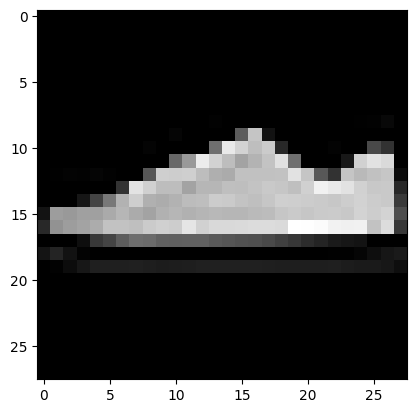

In [14]:
# Lets look at images at index 0, reshape the image so it is a 28 X 28 image
plt.imshow(images[0].reshape(28,28), cmap = 'gray')
plt.show

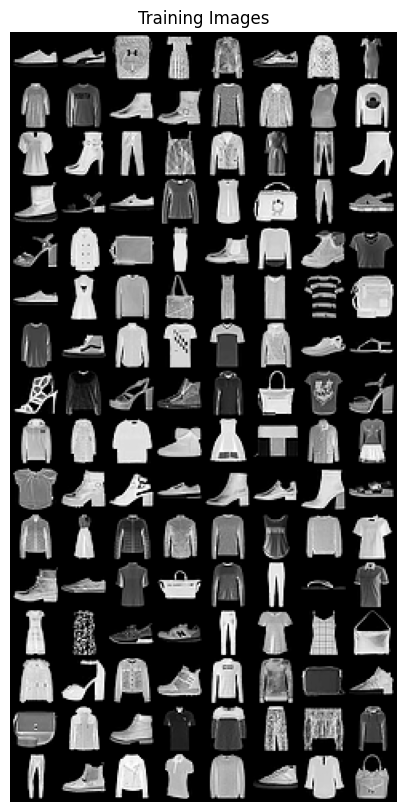

In [15]:
plt.figure(figsize = (12,10))

plt.axis('off')
plt.title('Training Images')

# padding of 2 pixels between each image in the grid
# normalize the image pixel values before they are displayed. (not necessary as pixel image is expressed between 0 and 1)
# transpose to switch around the dimensions of the image displayed from PyTorch to Matplotlib
#.  PyTorch (num of channels, height, width)
#.  Matplotlib (height, width, num of channels)
plt.imshow(np.transpose(make_grid(images.to(device), padding = 2, normalize = True).cpu(), (1,2,0)))
plt.show()

Setup an autoencoder using dense neural networks that makes up the encoder portion of the autoencoder

# The Encoder Network

> This class Encoder inherits from the nn.Module Base class.
> This is a base class in PyTorch that allows for construction of your neural network layers

The init method of the encoder takes in three input arguments - the dimensions of input layer, hidden layer and the latent codings.

> The first linear layer of the neural network.
    
    1. This takes in the input dimensions as an input. That is the in_features
  
    2. The out_features is equal to hidden dimension.

> The second linear layer, the number of in_features into the second linear layer is equal to the number of out_features from the first linear layer. It is this second linear layer that produces the codings of the autoencoder.

     1. The output of the first linear layer will feed into the input of the second linear layer.
     2. The number of out features in the second linear layer is equal to the latent dimensions.
     3. The size of our coding will be equal to latent_dim and latent_dim is smaller than the size of the input_dim

     4. That is why this is an undercomplete autoencoder.

> The forward function has been overwritten in nn.Module to define a forward pass through this encoder network.

      1. x is the input images passed in to this input layer.

      2. x that will be fed in will have the original dimensions:

      Flatten images to Feed into DNN
      [ batch_size, num_channels, height, width ] => [ batch_size, num_channels * height * width ]

      3. A dense neural network cannot deal with data in a multi-dimensional form.
      So we need to flatten the representation of these images.
      While preserving the batch dimension of the input image, it will flatten the rest of the image so that the images are represented as pixels, where the
      number of pixels is equal to:

      - number of channels times height times width

      - [128, 1, 28, 28] => [128, 784]
      the original batch of image tensors [128, 1, 28, 28] will be flattened so that each image is a single vector representation.

      The tensor fed in is of the dimensions [128,784] where 784=28*28

      This the return - This ReLU activated linear output is then passed through the second linear layer to produce the codings.













In [16]:
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.linear1 = nn.Linear(in_features = input_dim, out_features = hidden_dim)
    self.linear2 = nn.Linear(in_features = hidden_dim, out_features = latent_dim)

  def forward(self, x):
    x = x.view(-1, input_dim) # reshaping the input imaged by flatten
    x = F.relu(self.linear1(x)) # images are passed through the first linear layer
    return self.linear2(x)

# The Decoder Network

> This class Encoder inherits from the nn.Module Base class.

> At the input of the decoder, we feed in the latent representations of the images, the codings and the decoders responsibility is to reconstruct the original image from these codings.

The decoder also takes in the same three input arguments as the encoder
( the dimension of the original input, the hidden dimensions and latent dimensions - which is the size of the codings layer.)

   1. Number of input features = latent dimensions codings that are fed in

     a. The number of output features = hidden dimensions.

     b. These output features are then fed into the second linear layer.

     c. the output of the second linear layer of the decoder is the final output, thats why the out_features are equal to the input dimensions.

   2. Define a forward pass through this decoder

     a. The input argument z represents the codings or the latent representations produced by the encoder

     b. This is then passed into the first linear layer which has a ReLU activation

     c. The first linear layer is then passed through the second linear layer and to this we apply a sigmoid activation. This sigmoid activaiton is needed for the last linear layer from which the image output is produced. Because sigmoid outputs values in the range [0, 1] and those are te pixel intensity ranges for images.

     d. The images have been flattened as they flow through the dense neural network therefore we call z.reshape to reshape them back to the original format. [batch size, num channels, height, width]

     e. Observe that the layers in the encoder and decoder are symmetric. therefore this is a stacked undercomplete autoencoder.



In [17]:
class Decoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Decoder, self).__init__()

    self.linear1 = nn.Linear(in_features = latent_dim, out_features = hidden_dim)

    self.linear2 = nn.Linear(in_features = hidden_dim, out_features = input_dim)

  def forward(self, z):

    z = F.relu(self.linear1(z))

    z = torch.sigmoid(self.linear2(z))

    return z.reshape(-1, 1, 28, 28)

# Autoendcoder

- unsupervised training technique

The forward pass of the linear autoencoder first passes the input images x through the encoder, gets the codings/latent representations z, these codings are then passed through the decoder to get the reconstructed images


In [18]:
class LinearAutoencoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(LinearAutoencoder, self).__init__()

    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)

    self.decoder = Decoder(input_dim, hidden_dim, latent_dim)

  def forward(self, x):
    z = self.encoder(x)

    return self.decoder(z)

This display_images function will be called after every epoch of training with images from the validation data.

- We have to perform the transpose operation so that the images are in the form [height, width , number of channels]

- perform the same transpose operation height, width , number of channels to display the images.

In [19]:
def display_images(input, output, n_images = 10):
  n = 10
  plt.figure(figsize =(20,4))

  for i in range(n):

    #display original images
    ax = plt.subplot(2, n, i+1)
    item = input[i].permute(1,2,0)
    plt.imshow(item.cpu().detach().numpy(), cmap='gray') # to show original images
    plt.title(f'Original')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #display the reconstruction of images
    ax = plt.subplot(2, n, i+1+n)
    ops = output[i].view(-1,28, 28).permute(1,2,0)
    plt.imshow(ops.cpu().detach().numpy(), cmap='gray')
    plt.title(f'Reconstructed')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

  plt.show()

Input dimensions should be equal to the size of every image that we flatten and feed in.

- 1 * 28 * 28 = 784

The latent dimensions/ codings layer should have a size that is much smaller than the input.
Because the images are fairly simple and in grayscale

- latent dimensions = 2





In [20]:
# FashionMNIST image dimensions

input_dim = 1 * 28 * 28 #784
hidden_dim = 256
latent_dim = 2

Symmetric structure of this autoencoder

The model parameters of this autoencoder will be initialized with random values to start off with

In [21]:
model = LinearAutoencoder(input_dim, hidden_dim, latent_dim)
model.to(device)

LinearAutoencoder(
  (encoder): Encoder(
    (linear1): Linear(in_features=784, out_features=256, bias=True)
    (linear2): Linear(in_features=256, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (linear1): Linear(in_features=2, out_features=256, bias=True)
    (linear2): Linear(in_features=256, out_features=784, bias=True)
  )
)

Lets pass all the of the images from the training dataset through the encoder so that we get the latent representations in two dimensions.

Plot the latent representations, the encoder has not been trained therefore these latent representations are RANDOM


1. Iterate over all the batches in the training data
2. Pass those images through the encoder of the model
3. Display a scatter plot using the latent representation of those images.
4. Color all the data points based on the category of each image

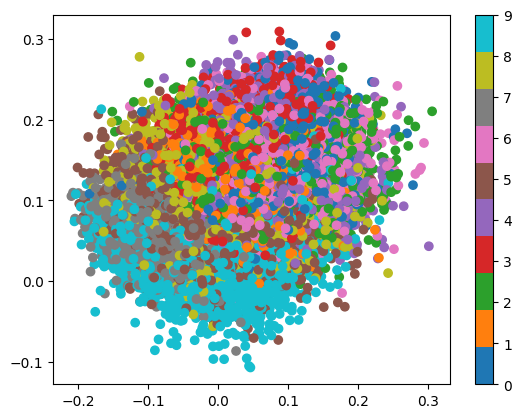

In [22]:
for i, (x,y) in enumerate(train_dl):
  z = model.encoder(x.to(device))
  z = z.to('cpu').detach().numpy()

  plt.scatter(z[:,0], z[:,1], c = y, cmap = 'tab10')

plt.colorbar()
plt.show()

Compute the MSELoss and use that to train the autoencoder.

In [23]:
epochs = 20

learning_rate = 0.001

batch_size = 128

criterion = nn.MSELoss() # mean square error loss ( reconstructed image vs input image)

optimizer = optim.Adam(model.parameters(), lr = learning_rate)

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 0 | Validation Loss: 0.17399


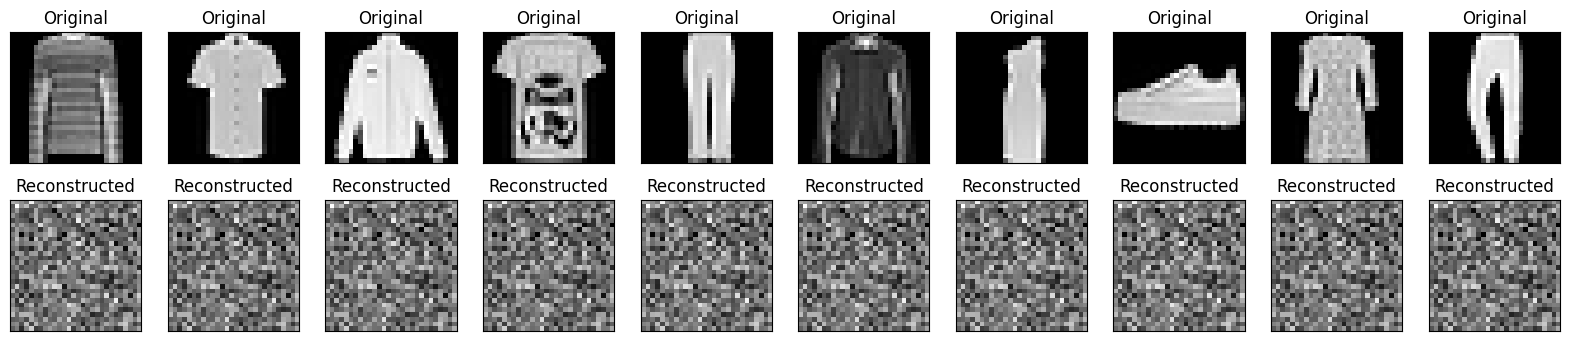

  5%|▍         | 1/21 [00:01<00:35,  1.79s/it]

Epoch 1 | Training Loss: 0.042
Epoch 1 | Validation Loss: 0.03415


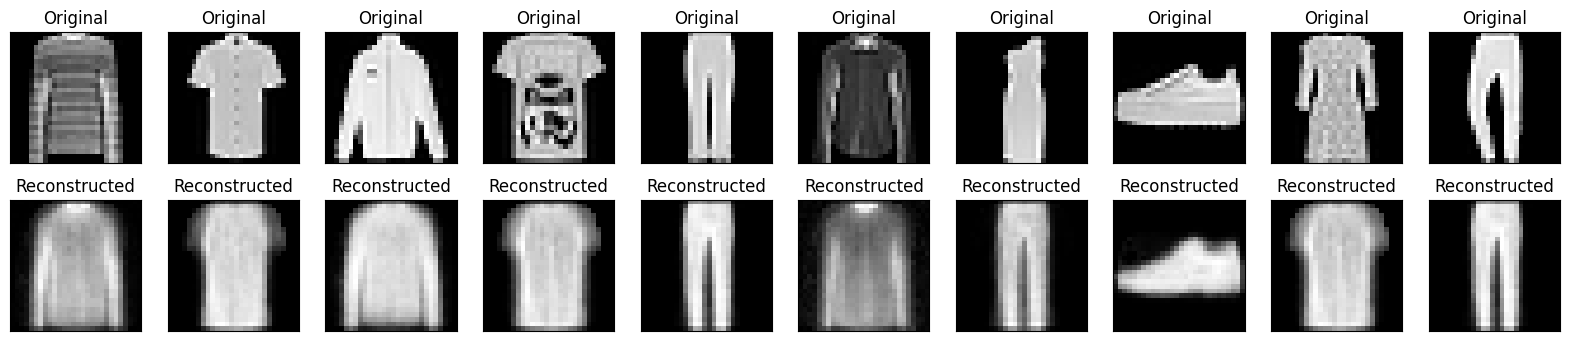

 10%|▉         | 2/21 [00:13<02:29,  7.89s/it]

Epoch 2 | Training Loss: 0.033
Epoch 2 | Validation Loss: 0.03239


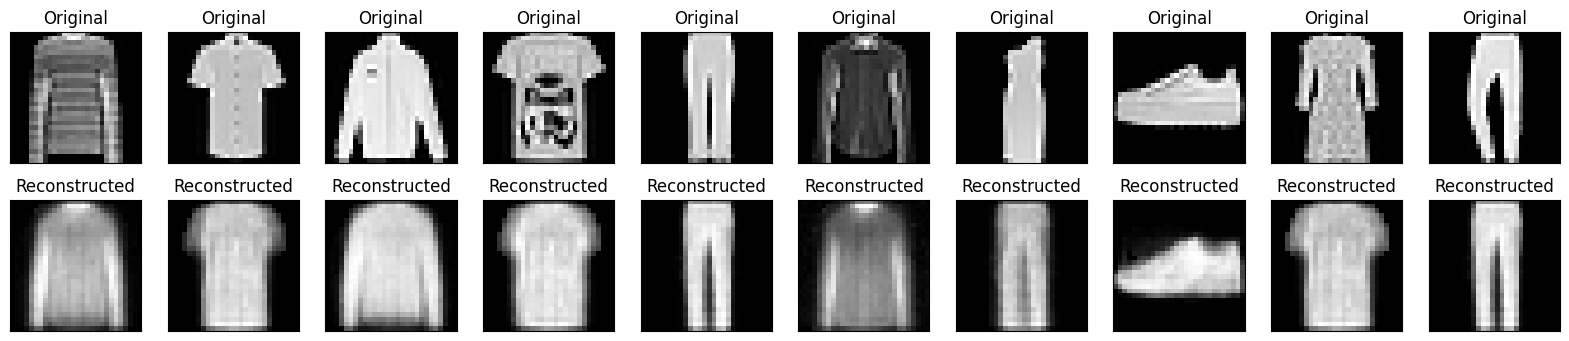

 14%|█▍        | 3/21 [00:26<03:00, 10.00s/it]

Epoch 3 | Training Loss: 0.032
Epoch 3 | Validation Loss: 0.03145


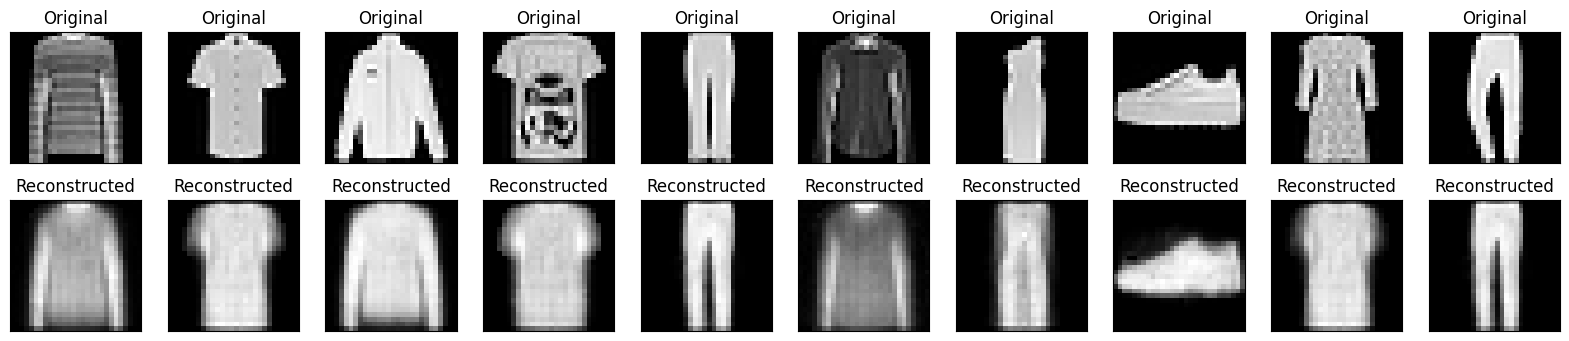

 19%|█▉        | 4/21 [00:38<03:06, 10.95s/it]

Epoch 4 | Training Loss: 0.031
Epoch 4 | Validation Loss: 0.03096


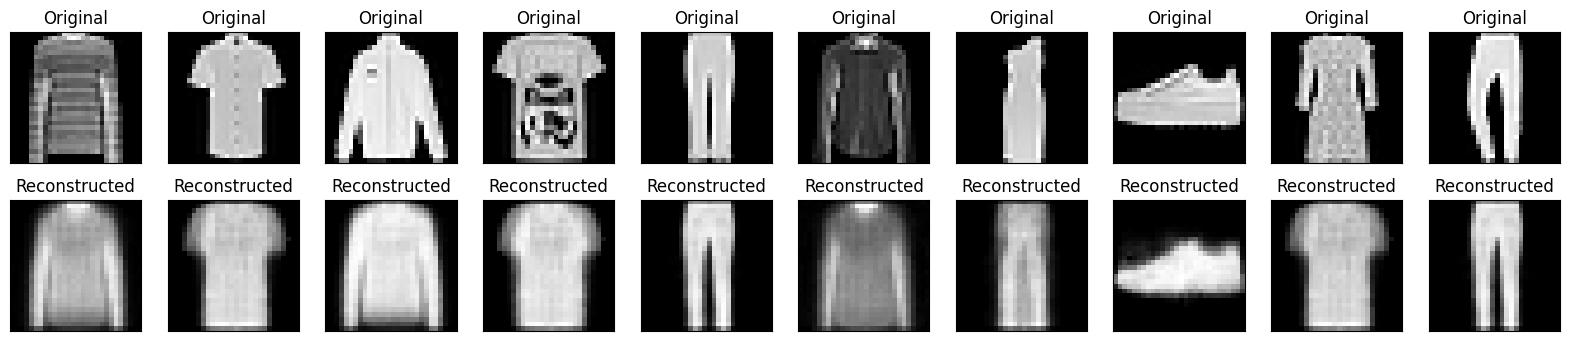

 24%|██▍       | 5/21 [00:52<03:11, 11.98s/it]

Epoch 5 | Training Loss: 0.031
Epoch 5 | Validation Loss: 0.03069


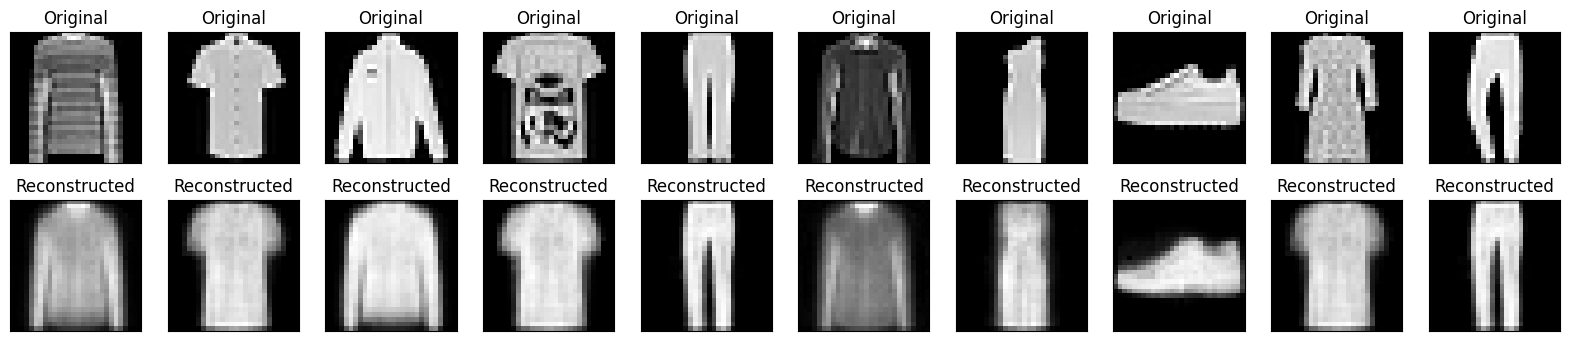

 29%|██▊       | 6/21 [01:06<03:09, 12.64s/it]

Epoch 6 | Training Loss: 0.030
Epoch 6 | Validation Loss: 0.03013


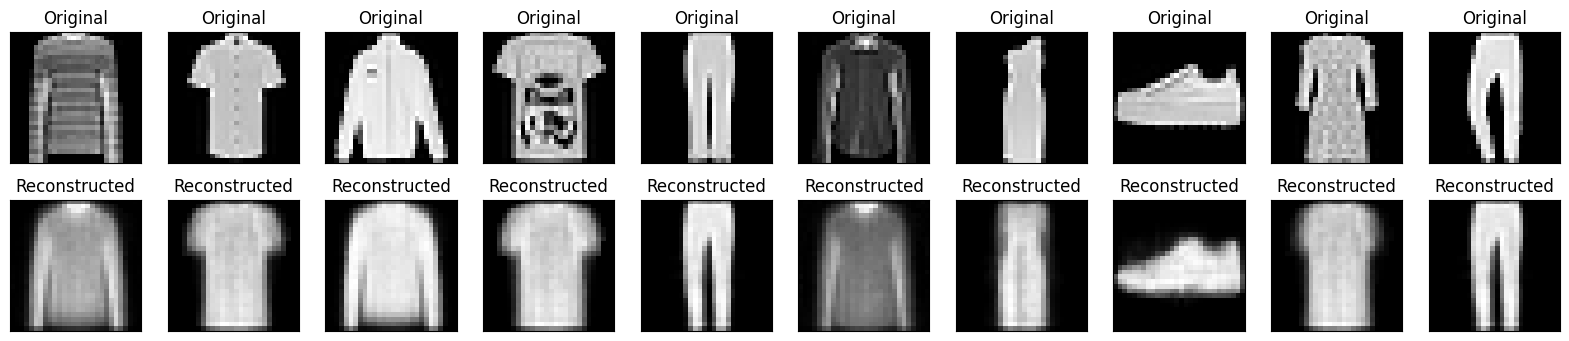

 33%|███▎      | 7/21 [01:19<03:00, 12.87s/it]

Epoch 7 | Training Loss: 0.030
Epoch 7 | Validation Loss: 0.03018


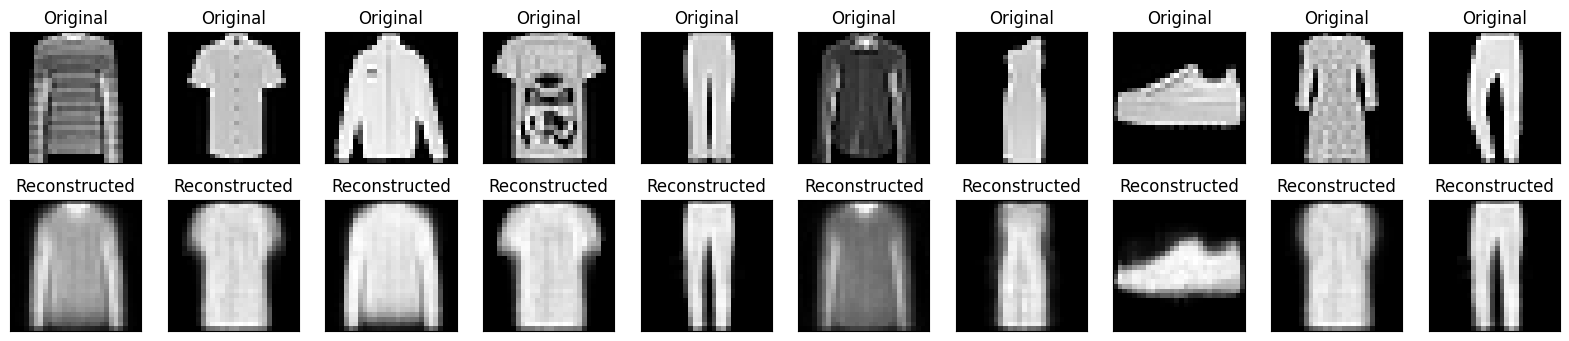

 38%|███▊      | 8/21 [01:33<02:49, 13.03s/it]

Epoch 8 | Training Loss: 0.030
Epoch 8 | Validation Loss: 0.02969


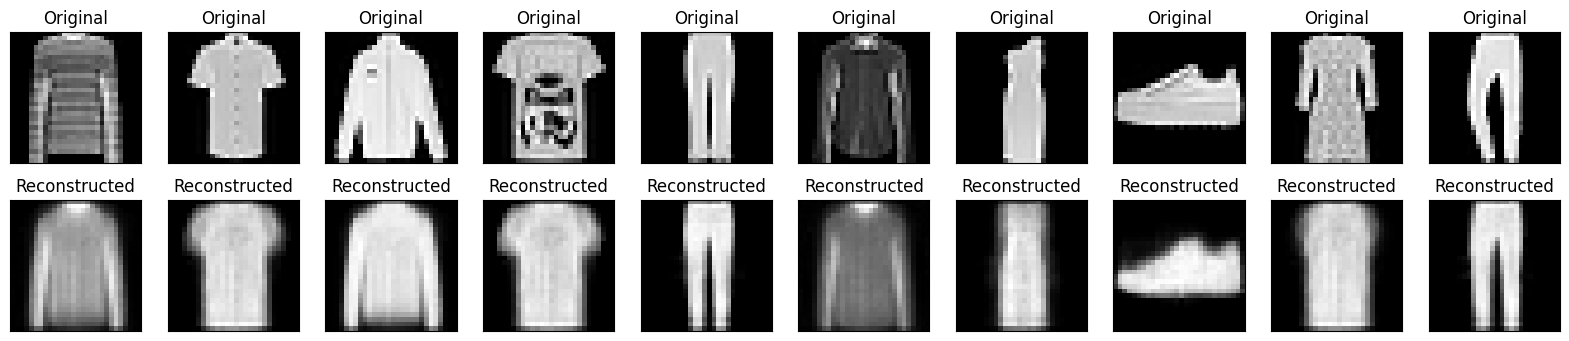

 43%|████▎     | 9/21 [01:46<02:38, 13.23s/it]

Epoch 9 | Training Loss: 0.029
Epoch 9 | Validation Loss: 0.02950


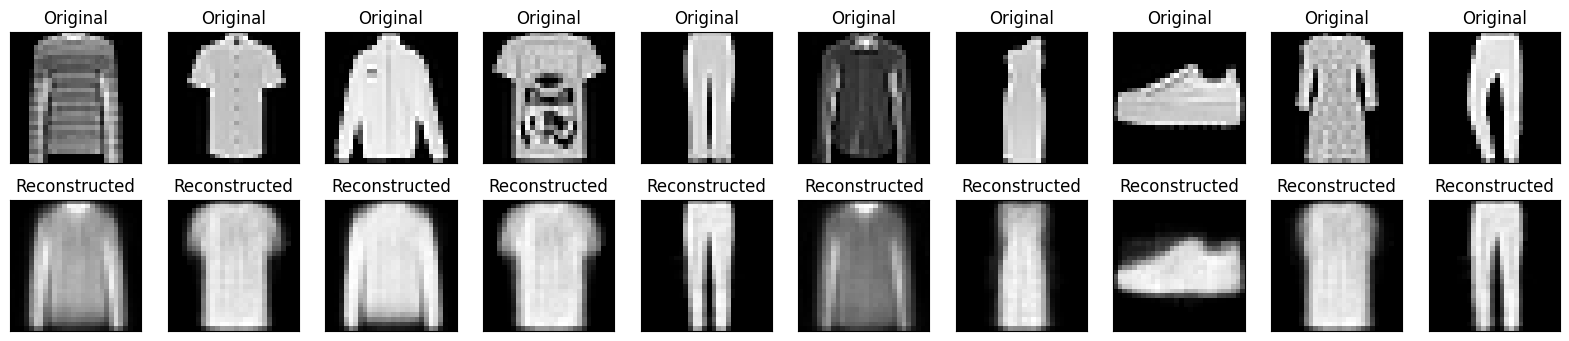

 48%|████▊     | 10/21 [02:06<02:45, 15.09s/it]

Epoch 10 | Training Loss: 0.029
Epoch 10 | Validation Loss: 0.02933


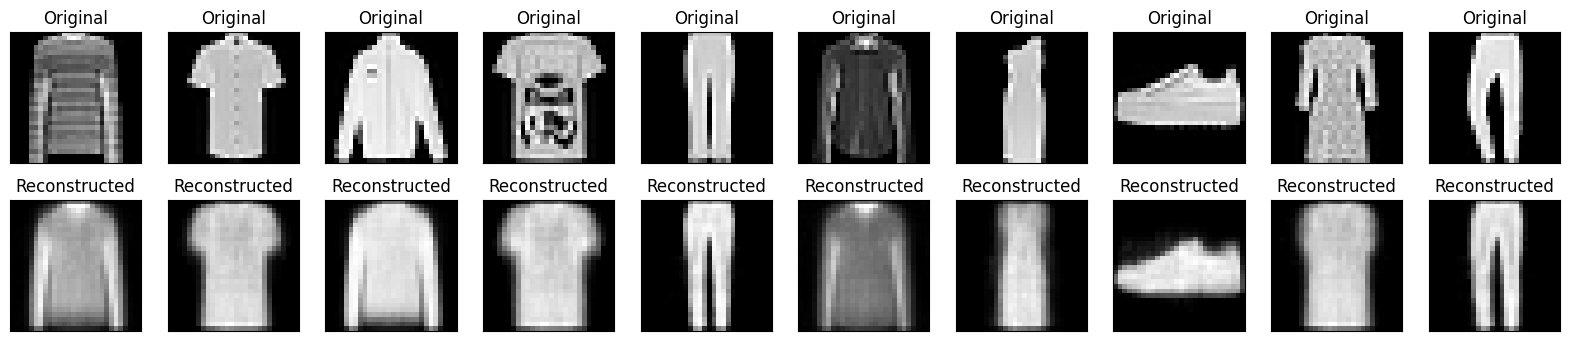

 52%|█████▏    | 11/21 [02:30<03:00, 18.01s/it]

Epoch 11 | Training Loss: 0.029
Epoch 11 | Validation Loss: 0.02915


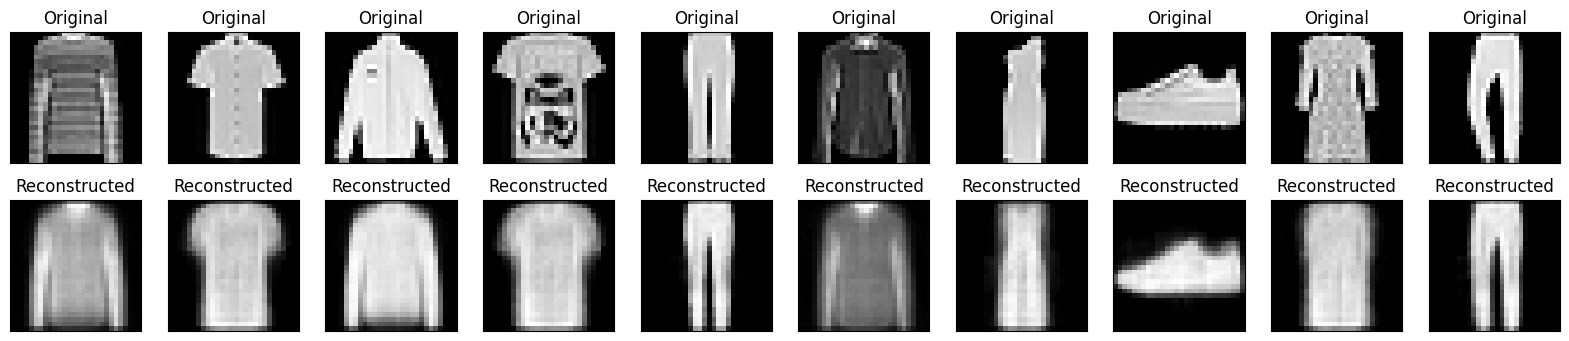

 57%|█████▋    | 12/21 [02:45<02:32, 16.98s/it]

Epoch 12 | Training Loss: 0.029
Epoch 12 | Validation Loss: 0.02920


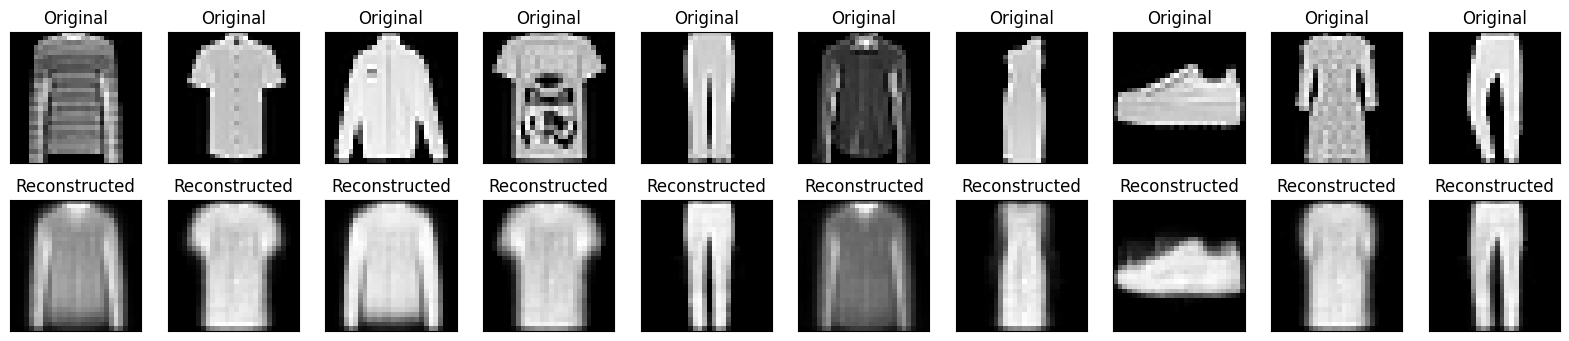

 62%|██████▏   | 13/21 [03:00<02:11, 16.39s/it]

Epoch 13 | Training Loss: 0.029
Epoch 13 | Validation Loss: 0.02910


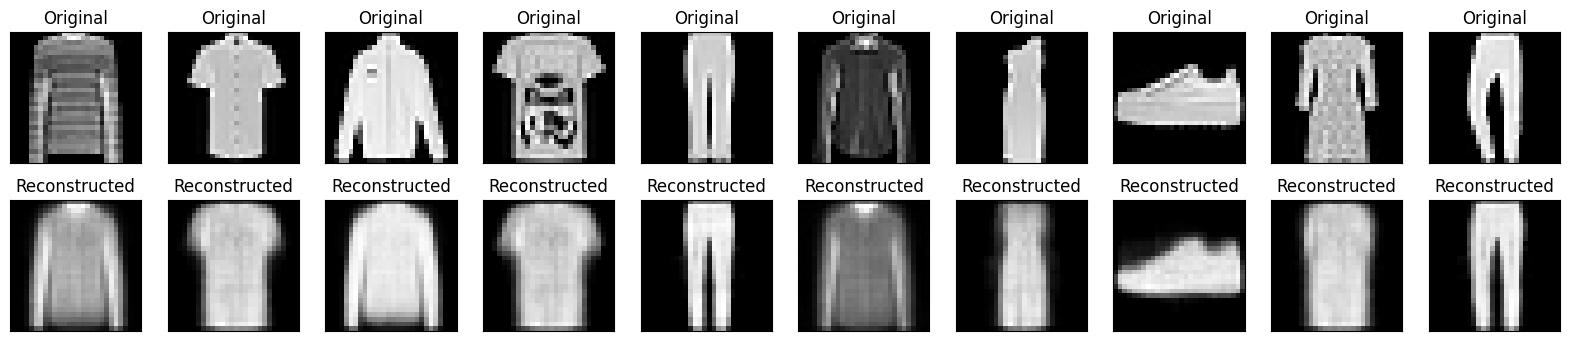

 67%|██████▋   | 14/21 [03:14<01:50, 15.77s/it]

Epoch 14 | Training Loss: 0.029
Epoch 14 | Validation Loss: 0.02882


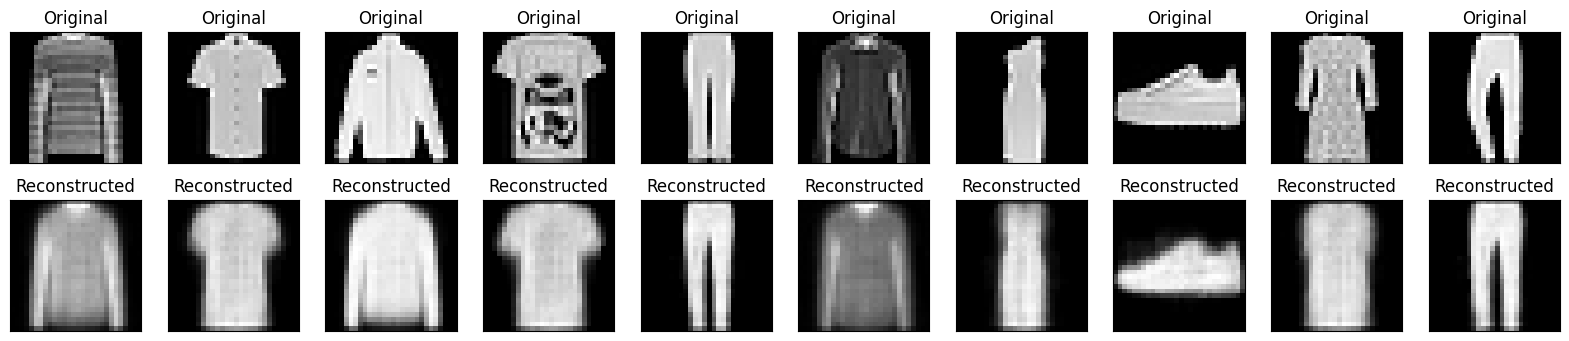

 71%|███████▏  | 15/21 [03:30<01:34, 15.75s/it]

Epoch 15 | Training Loss: 0.029
Epoch 15 | Validation Loss: 0.02872


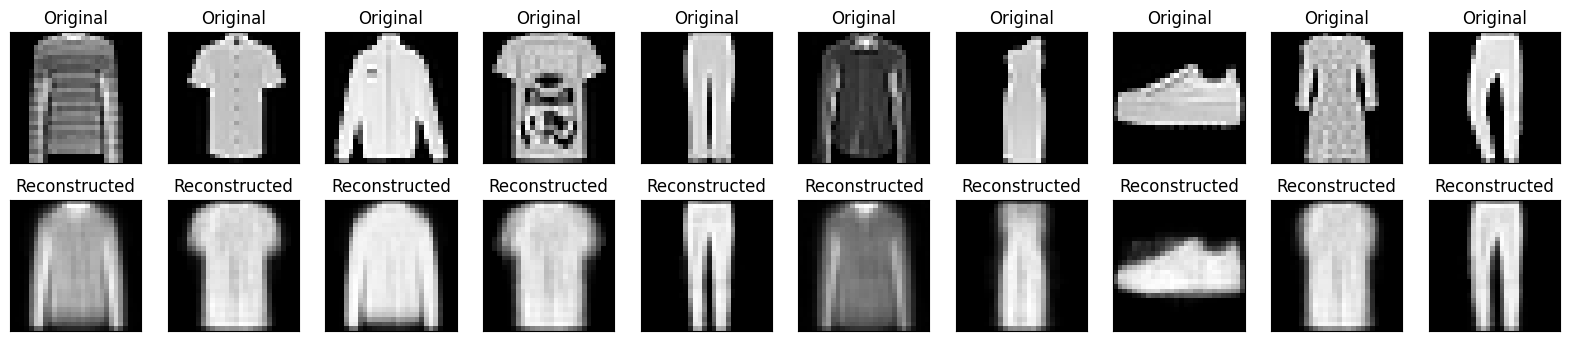

 76%|███████▌  | 16/21 [03:45<01:18, 15.63s/it]

Epoch 16 | Training Loss: 0.029
Epoch 16 | Validation Loss: 0.02865


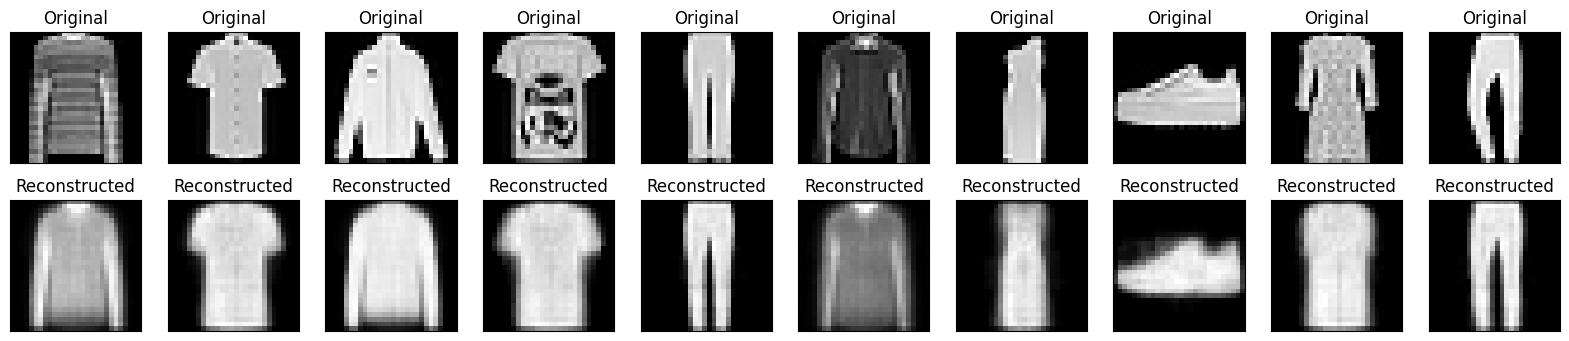

 81%|████████  | 17/21 [04:00<01:01, 15.37s/it]

Epoch 17 | Training Loss: 0.028
Epoch 17 | Validation Loss: 0.02879


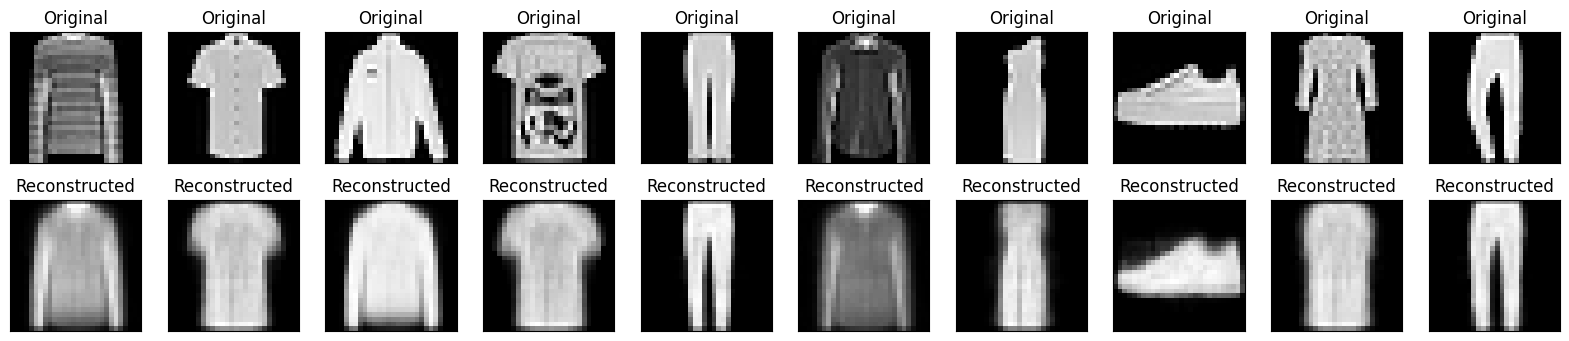

 86%|████████▌ | 18/21 [04:16<00:46, 15.39s/it]

Epoch 18 | Training Loss: 0.028
Epoch 18 | Validation Loss: 0.02851


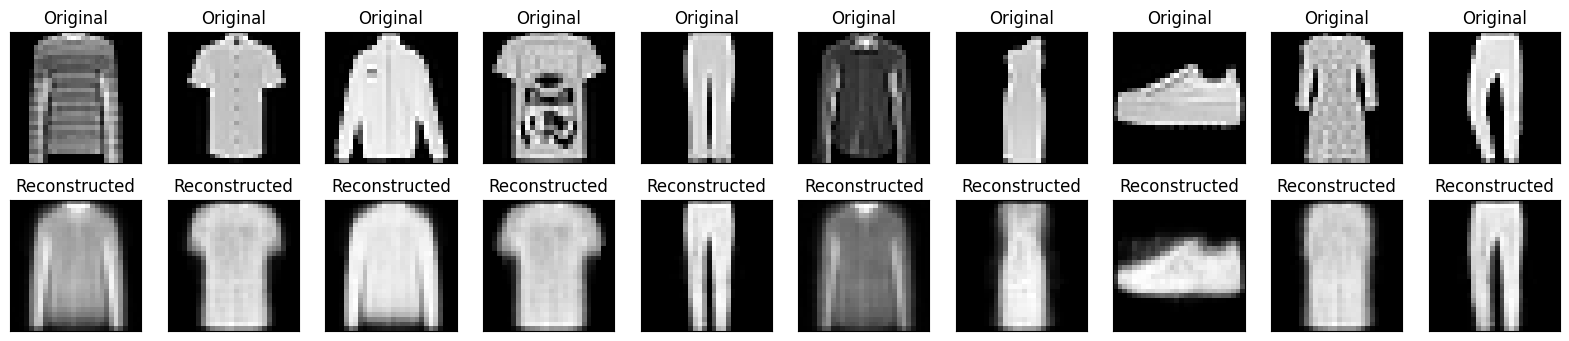

 90%|█████████ | 19/21 [04:31<00:30, 15.27s/it]

Epoch 19 | Training Loss: 0.028
Epoch 19 | Validation Loss: 0.02838


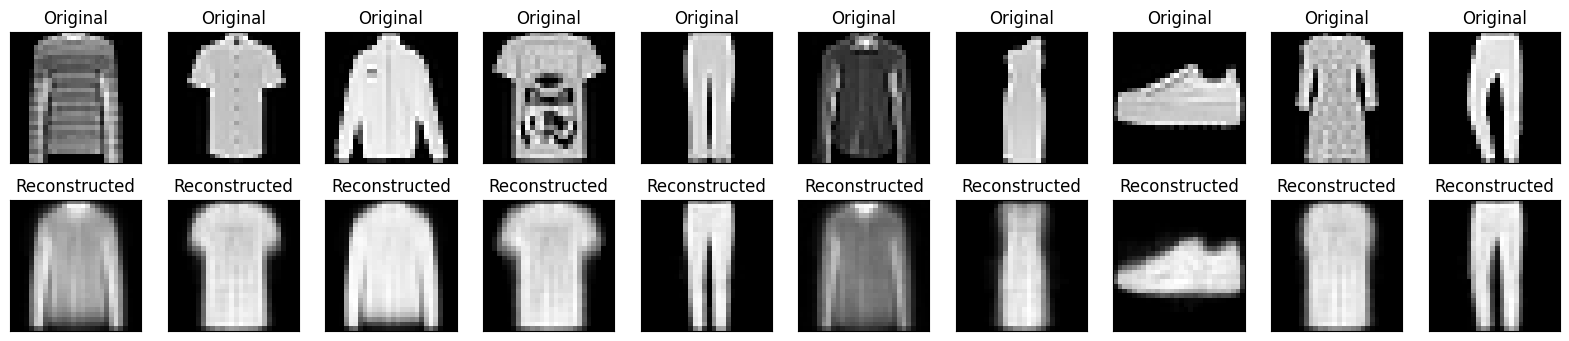

 95%|█████████▌| 20/21 [04:46<00:15, 15.22s/it]

Epoch 20 | Training Loss: 0.028
Epoch 20 | Validation Loss: 0.02843


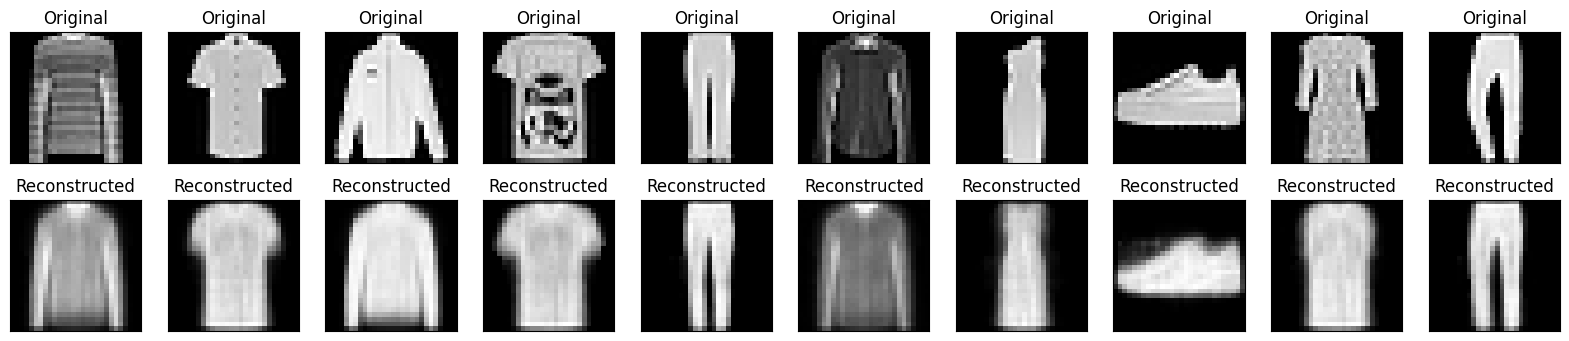

100%|██████████| 21/21 [05:01<00:00, 14.34s/it]


In [24]:
train_loss_list = [] # keep track of the lost function on the training and validation set
val_loss_list = []

for epoch in tqdm(range(epochs + 1)):  #tqdm to show progress bar with each epochs of training.
  if epoch > 0: #start training when epoch is 1 which is the second epoch
    model.train() # model is in training mode
    train_running_loss = 0.0

    for i ,(X_train, y) in enumerate(train_dl): # nested for loop though the batches of training data - X_train: images, y: labels
      X_train = X_train.to(device)
      optimizer.zero_grad()

      reconstructed_X_train = model(X_train) #forward pass through the autoencoder

      loss = criterion(reconstructed_X_train, X_train) #comapred the reconstructed images with the original and computer the mean square error loss

      loss.backward() #compute the gradients for the model parameters

      train_running_loss += loss.item() # sum the loss

      optimizer.step() #update the model parameters

    train_loss = train_running_loss / len(train_dl) #compute the training loss for the epoch
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch} | Training Loss: {train_loss:.3f}') #print the training loss

  with torch.no_grad():
    model.eval()
    val_running_loss = 0.0

    for i, (X_val, y) in enumerate(valid_dl):
      X_val = X_val.to(device)

      reconstructed_X_val = model(X_val)

      loss = criterion(reconstructed_X_val, X_val)
      val_running_loss += loss.item()

    val_loss = val_running_loss / len(valid_dl)
    val_loss_list.append(val_loss)

  print(f'Epoch {epoch} | Validation Loss: {val_loss:.5f}')
  display_images(X_val, reconstructed_X_val, 10)

The training loss improved gradually and the reconstructed images become move clear with each epoch

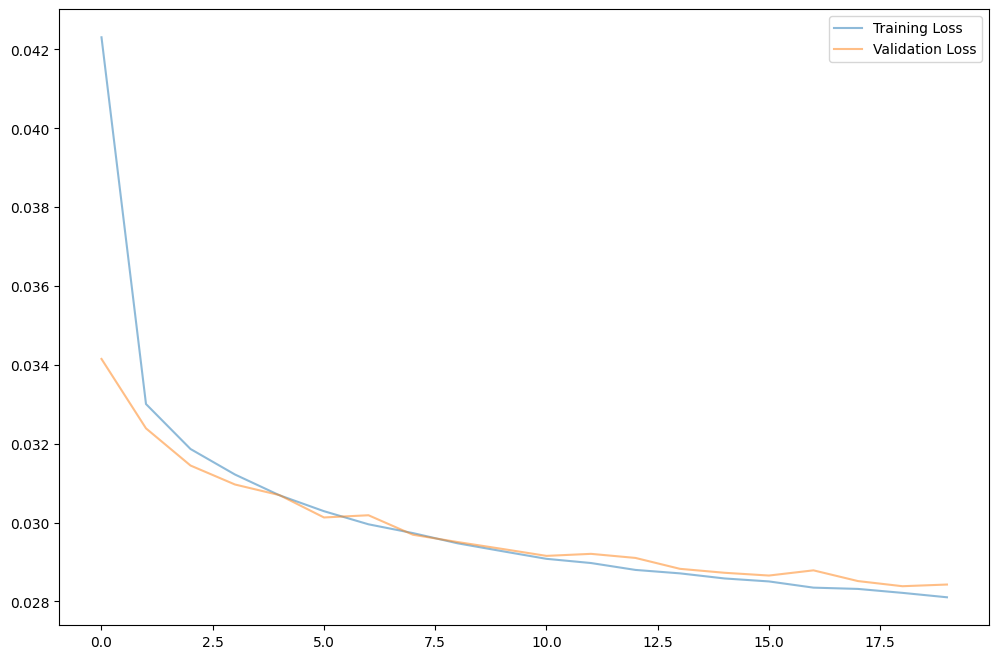

In [25]:
fig, (ax) = plt.subplots(1,1, figsize =(12,8))

ax.plot(train_loss_list, label = "Training Loss", alpha = 0.5)
ax.plot(val_loss_list[1:], label = "Validation Loss", alpha = 0.5)

ax.legend()

In [26]:
test_images, _ = next(iter(test_dl))
test_images = test_images.to(device)

reconstructed_test_images = model(test_images)

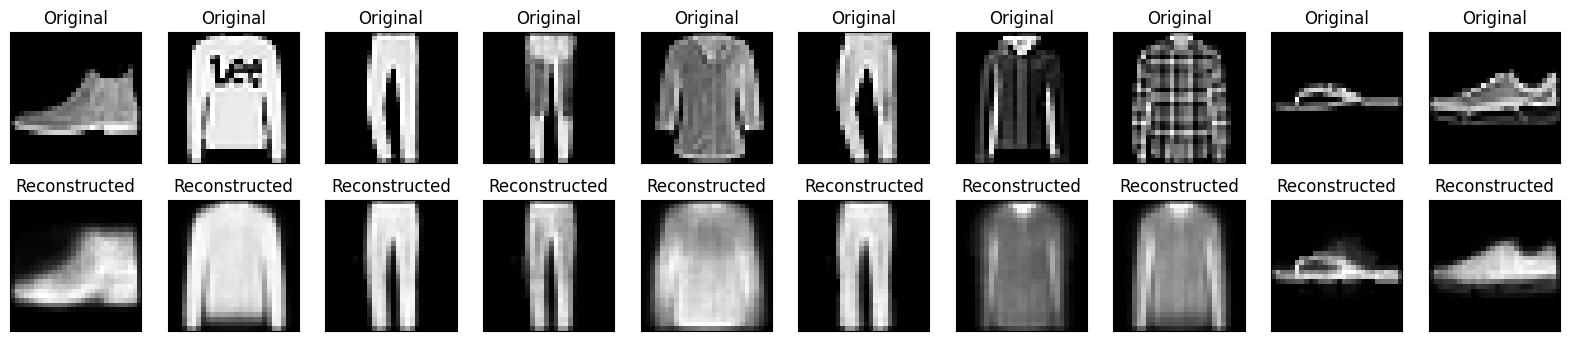

In [27]:
display_images(test_images, reconstructed_test_images, 10)

Pass the training data through our trained encoder

- now the categories are starting to form clusters

- categories that are close together or overalapping each other indicate how similar to the articles of clothing for example : ankle boot, sandal and sneaker are closely related.

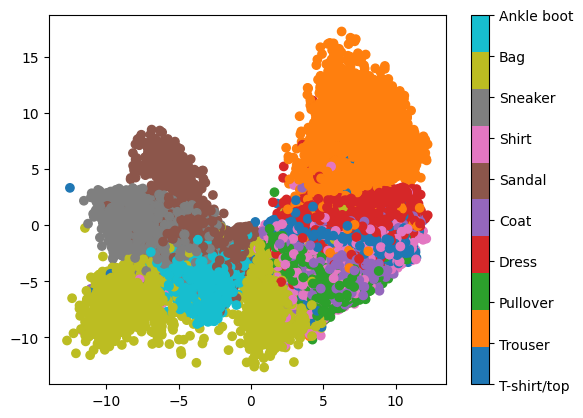

In [28]:
for i, (x,y) in enumerate(train_dl):
  z = model.encoder(x.to(device))
  z = z.to('cpu').detach().numpy()
  plt.scatter(z[:,0], z[:,1], c = y, cmap = 'tab10')

# Get class names from the dataset
class_names = train_data.dataset.classes
num_classes = len(class_names)

# Create a colorbar with labeled ticks
cbar = plt.colorbar(ticks=range(num_classes))
cbar.set_ticklabels(class_names)
plt.show()

# Train an AutoEncoder using a Convolutional Neural Network

> Convolutional layers is used to extract feature maps from input images.

> Pooling layers are used to sub-sample or down sample the input image data

> The Encoder will generate the latent representations of the input images. The latent representations will be in the form of 3D feature maps. The output of the encoder, the latent representations will be passed through the decoder.

- in_channel = 1 because we are working with grayscale images
- out_channels this feature map will produce 16 feature map at the output
- The ReLU activation function should be applied in place

- The MaxPool2d layer in a convolutional neural network is used for downsampling or sub-sampling feature maps

- kernel_size: The size of the window to take the maximum over (e.g., 2 for a 2x2 window).

- stride: The step size with which the window moves across the input (e.g., 2 means it moves 2 pixels at a time, resulting in a 2x reduction in dimensions)

> The Decoder will try to reconstruct the original images from the latent representations.

- Tranpose convolutional layers are used fot unsampling the input image.

- In the decoder we want to upsample the latent representations to get the original reconstructed image.

- in_channels need to match the out_channels of the endcoder

- final out_channels just has 1 channel since its a grayscale reconstructed image.

- Sigmoid activation produces values in range [0,1] which matches the pixel intensity values range  of the reconstructed grayscale image.

> The Autoencoder must be symmetric
- For every convolutional and max pooling layer that results in feature map generation and down sampling of inputs, we have a transpose convolutional layer upsampling the inputs.



In [29]:
class ConvAutoencoder(nn.Module):
  def __init__(self):
    super(ConvAutoencoder, self).__init__()

    #Encoder
    self.encoder = nn.Sequential(
        nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 3, padding = 1 ),
        nn.ReLU(True),
        nn.MaxPool2d(kernel_size = 2, stride = 2),

        nn.Conv2d(in_channels = 16, out_channels = 4, kernel_size = 3, padding = 1),
        nn.ReLU(True),
        nn.MaxPool2d(kernel_size = 2, stride = 2))

    #Decoder
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(in_channels = 4, out_channels = 16, kernel_size = 2, stride = 2 ),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels = 16, out_channels = 1, kernel_size = 2, stride = 2 ),
        nn.Sigmoid()) # Corrected typo: nn.Sigmoif() -> nn.Sigmoid()

  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x

In [30]:
model = ConvAutoencoder().to(device)
model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

In [31]:
learning_rate = 1e-3
epochs = 20
criterion = nn.MSELoss() #loss between reconstructed images
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [32]:
def display_images(input, output, n_images = 10):
  n = 10
  plt.figure(figsize =(20,4))

  for i in range(n):

    #display original images
    ax = plt.subplot(2, n, i+1)
    item = input[i].permute(1,2,0)
    plt.imshow(item.cpu().detach().numpy(), cmap='gray') # to show original images
    plt.title(f'Original')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #display the reconstruction of images
    ax = plt.subplot(2, n, i+1+n)
    ops = output[i].view(-1,28, 28).permute(1,2,0)
    plt.imshow(ops.cpu().detach().numpy(), cmap='gray')
    plt.title(f'Reconstructed')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

  plt.show()

### Training Process

1. Access the training data, move it to the CPU/GPU
2. Make a forward pass through the model, get the reconstructed outputs
3. Compute the loss, make a backward pass through the model to compute gradients.
4. Update the model parameters using these gradients
5. For every epoch of training, we print out the training loss
6. Compute the loss on the validation data and print the loss after every epoch

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 0 | Validation Loss: 0.17736


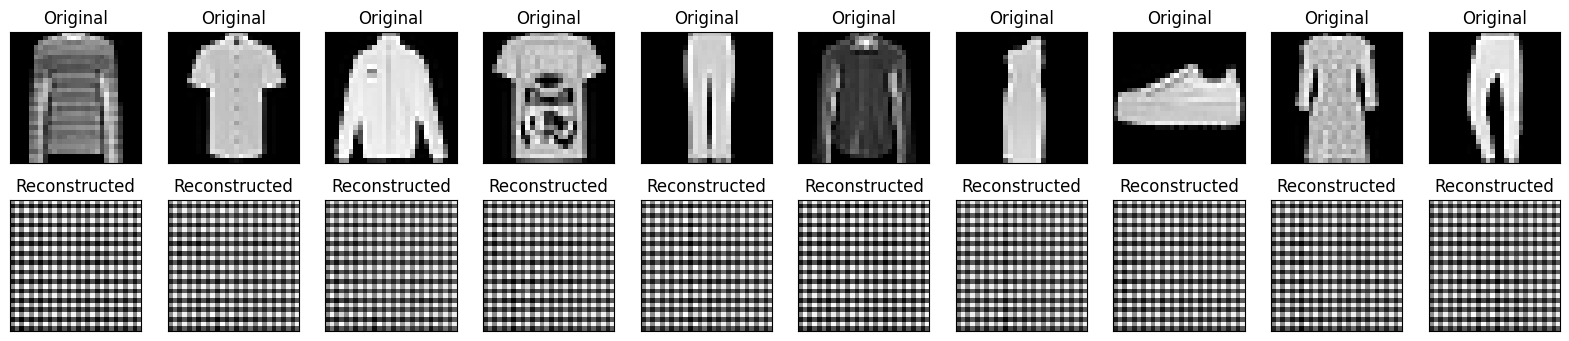

  5%|▍         | 1/21 [00:03<01:12,  3.62s/it]

Epoch 1 | Training Loss: 0.065
Epoch 1 | Validation Loss: 0.01986


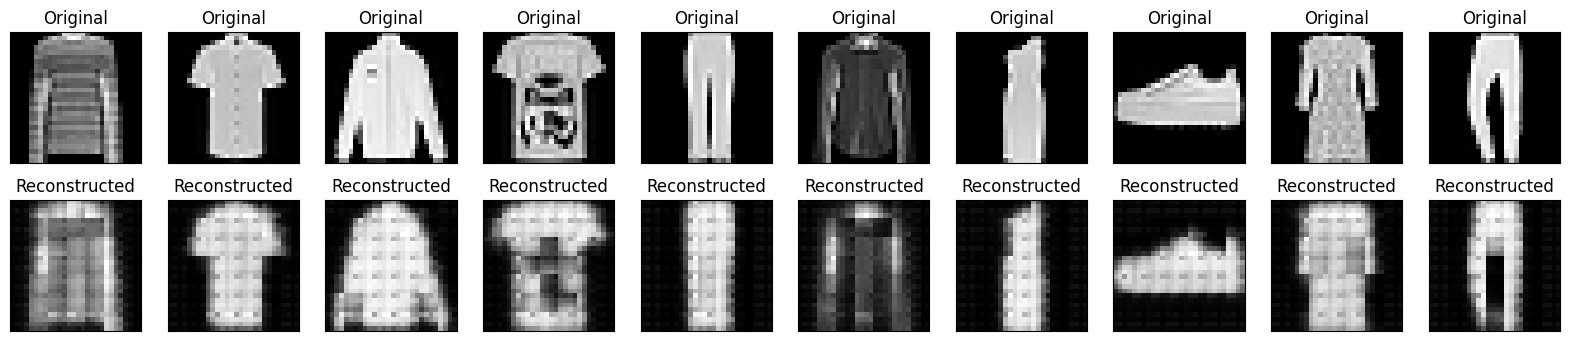

 10%|▉         | 2/21 [00:35<06:26, 20.32s/it]

Epoch 2 | Training Loss: 0.018
Epoch 2 | Validation Loss: 0.01732


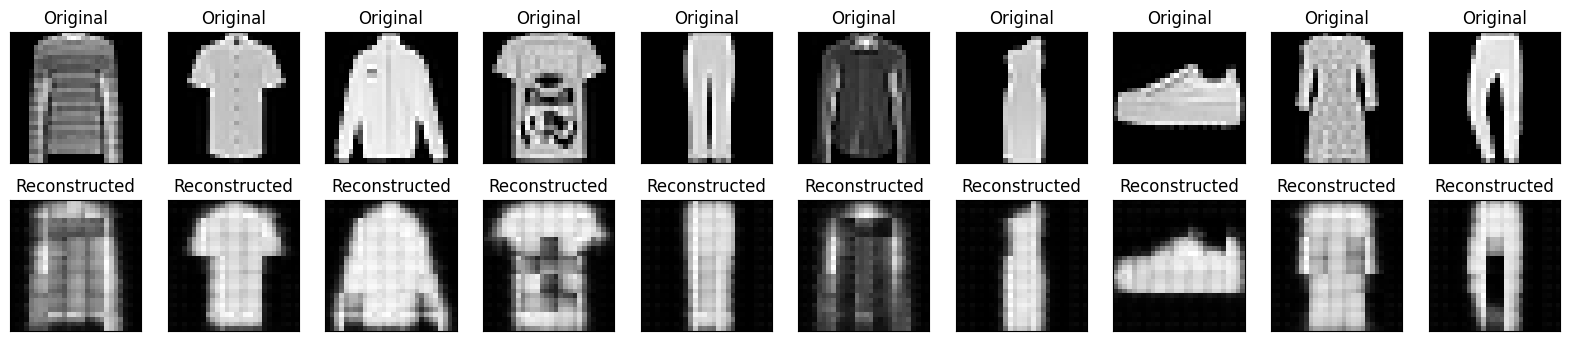

 14%|█▍        | 3/21 [01:05<07:27, 24.86s/it]

Epoch 3 | Training Loss: 0.017
Epoch 3 | Validation Loss: 0.01649


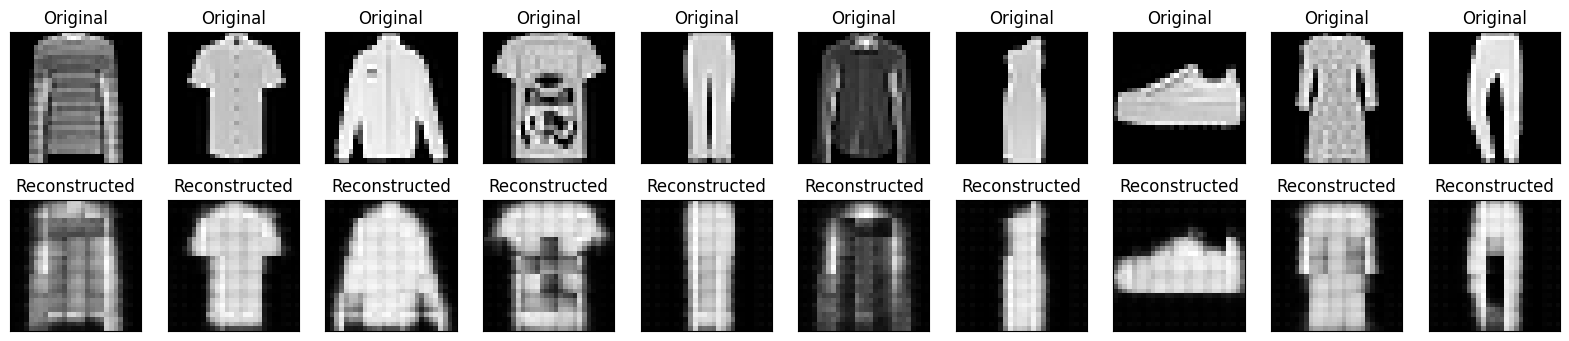

 19%|█▉        | 4/21 [01:38<07:54, 27.89s/it]

Epoch 4 | Training Loss: 0.016
Epoch 4 | Validation Loss: 0.01582


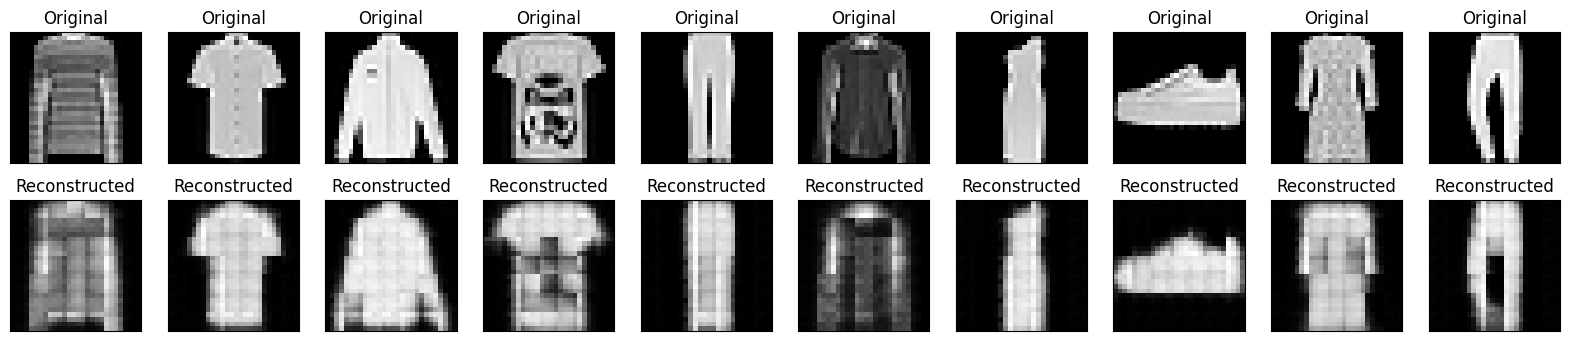

 24%|██▍       | 5/21 [02:13<08:06, 30.42s/it]

Epoch 5 | Training Loss: 0.016
Epoch 5 | Validation Loss: 0.01546


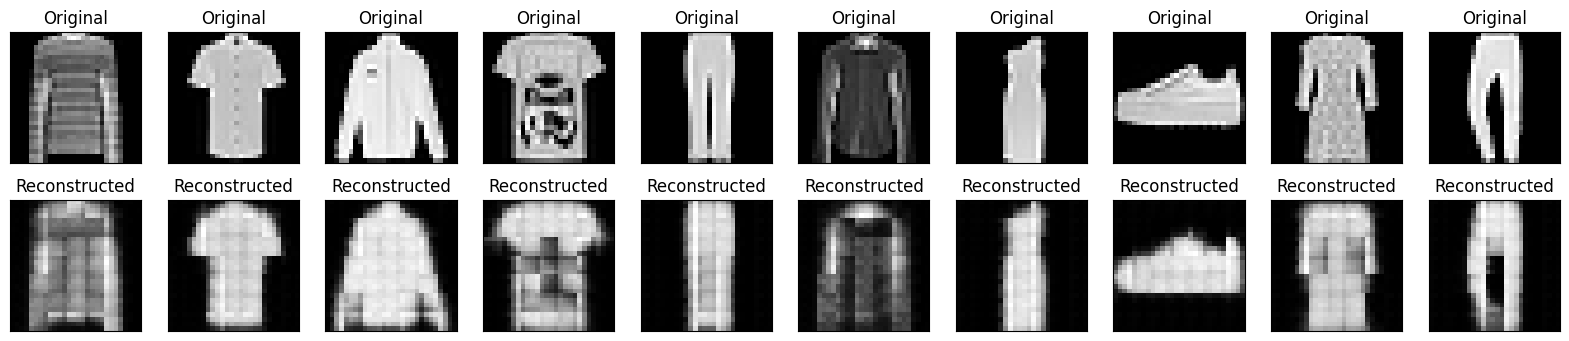

 29%|██▊       | 6/21 [02:48<08:02, 32.18s/it]

Epoch 6 | Training Loss: 0.015
Epoch 6 | Validation Loss: 0.01516


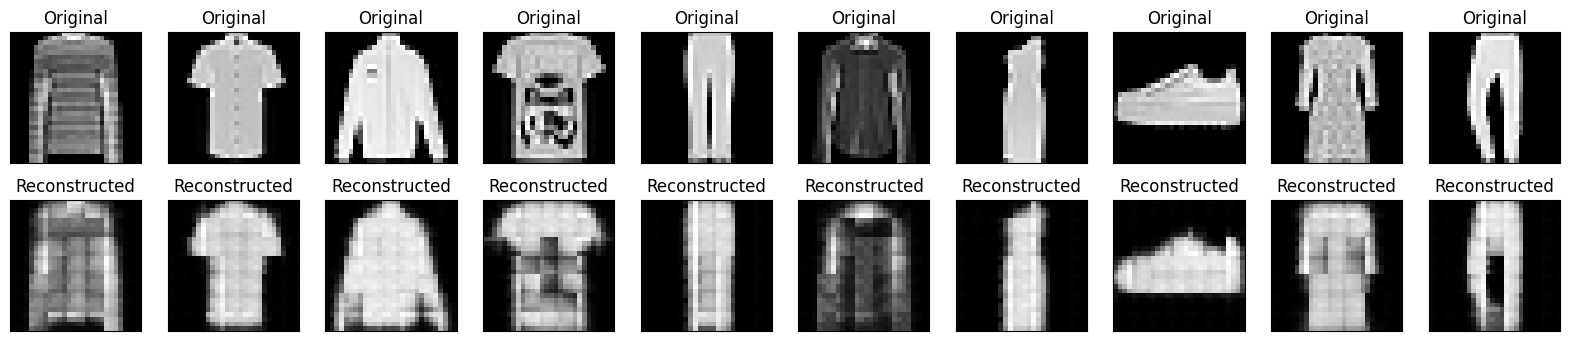

 33%|███▎      | 7/21 [03:23<07:41, 32.98s/it]

Epoch 7 | Training Loss: 0.015
Epoch 7 | Validation Loss: 0.01494


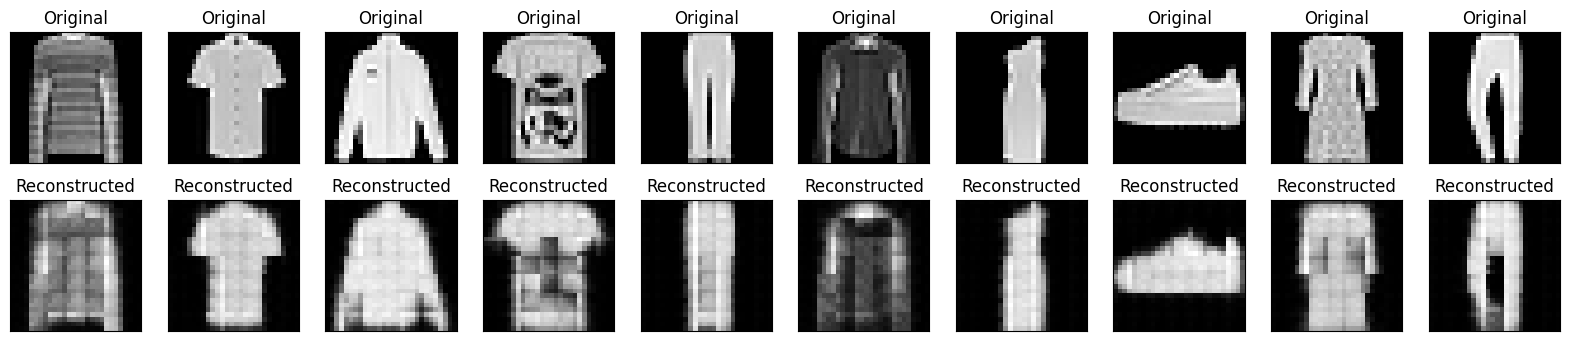

 38%|███▊      | 8/21 [03:53<06:57, 32.15s/it]

Epoch 8 | Training Loss: 0.015
Epoch 8 | Validation Loss: 0.01472


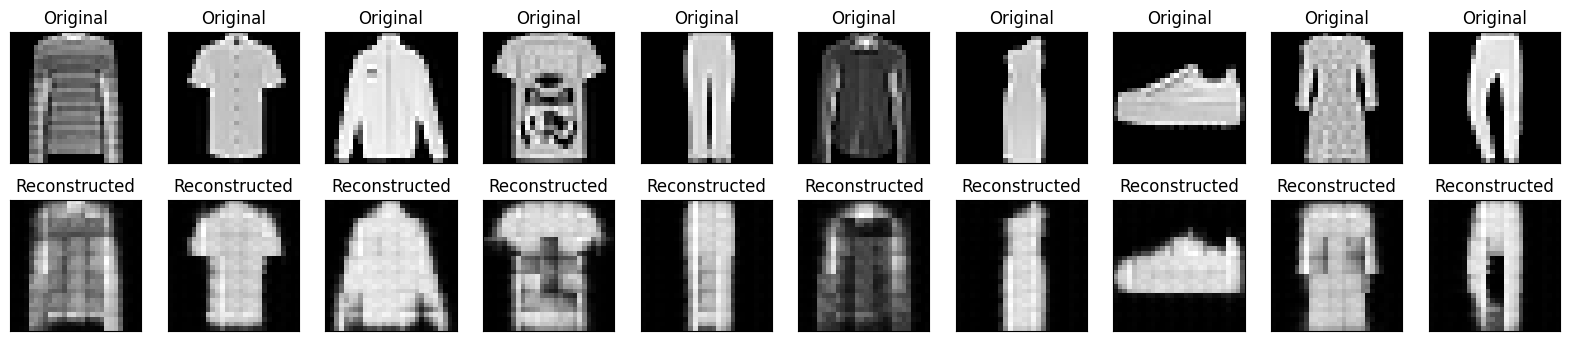

 43%|████▎     | 9/21 [04:33<06:52, 34.37s/it]

Epoch 9 | Training Loss: 0.015
Epoch 9 | Validation Loss: 0.01452


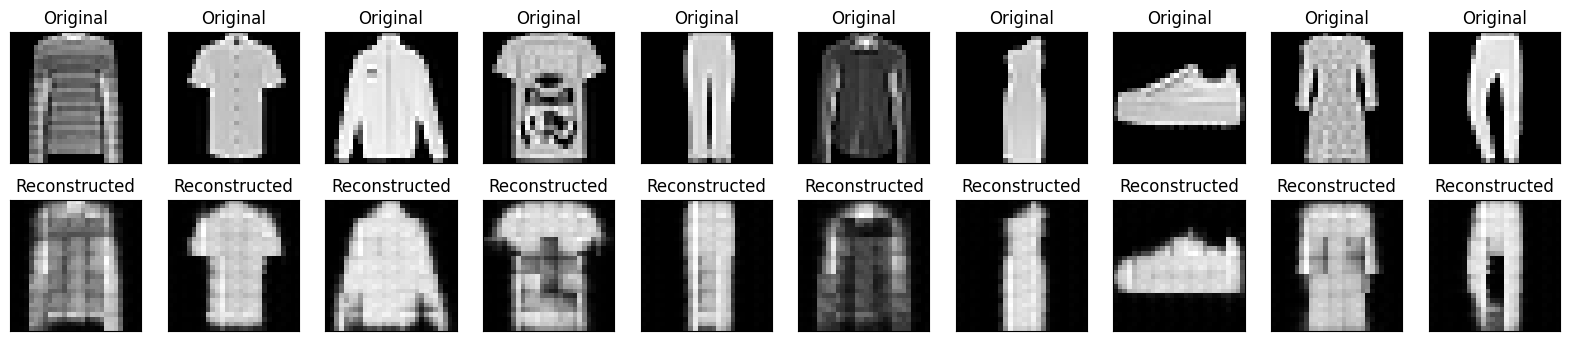

 48%|████▊     | 10/21 [05:09<06:26, 35.12s/it]

Epoch 10 | Training Loss: 0.014
Epoch 10 | Validation Loss: 0.01434


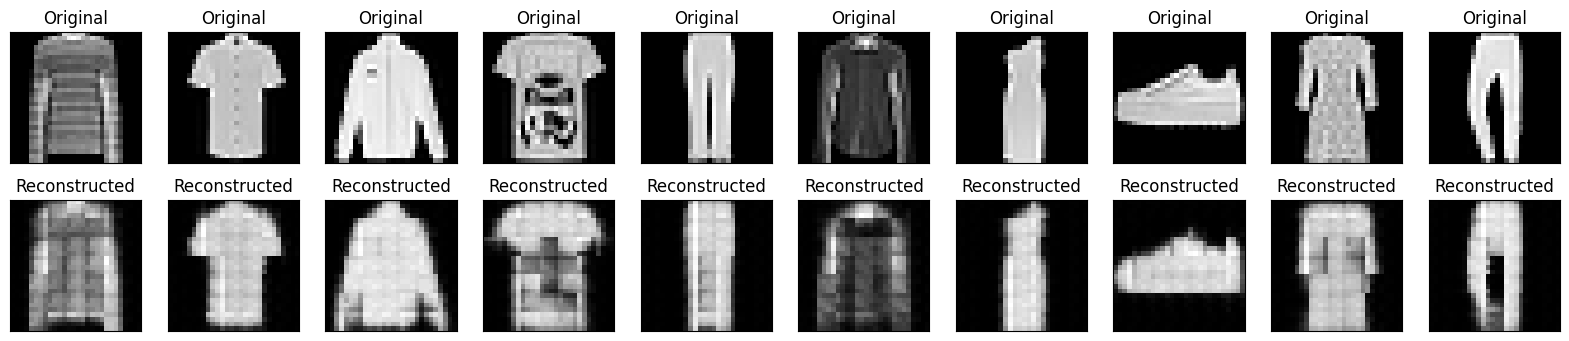

 52%|█████▏    | 11/21 [05:41<05:41, 34.13s/it]

Epoch 11 | Training Loss: 0.014
Epoch 11 | Validation Loss: 0.01413


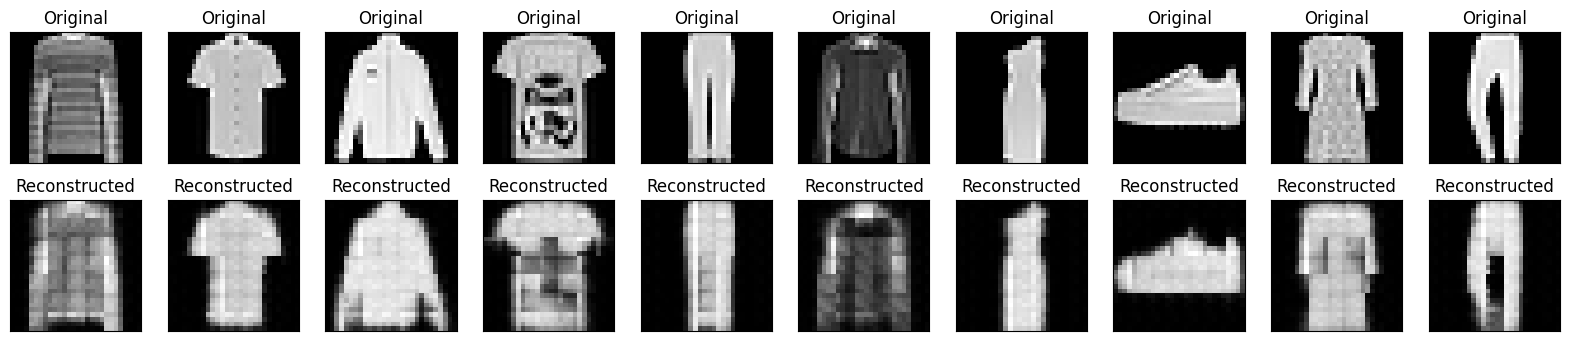

 57%|█████▋    | 12/21 [06:19<05:18, 35.33s/it]

Epoch 12 | Training Loss: 0.014
Epoch 12 | Validation Loss: 0.01393


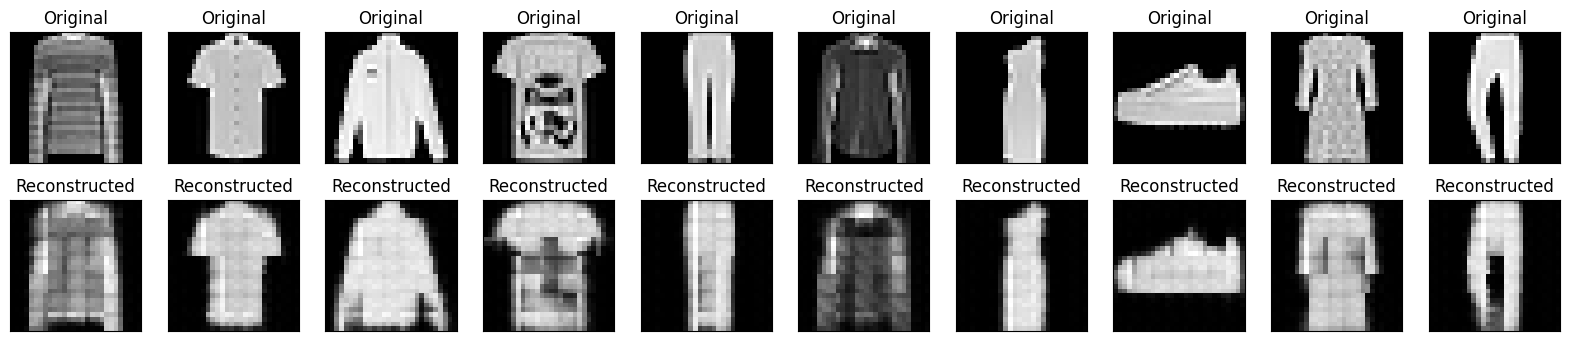

 62%|██████▏   | 13/21 [06:55<04:42, 35.37s/it]

Epoch 13 | Training Loss: 0.014
Epoch 13 | Validation Loss: 0.01376


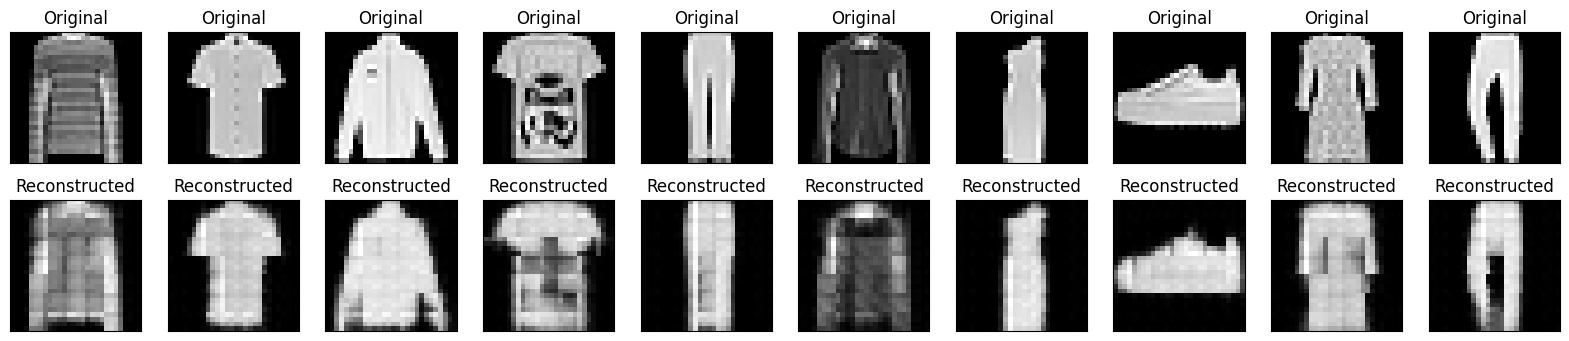

 67%|██████▋   | 14/21 [07:30<04:08, 35.44s/it]

Epoch 14 | Training Loss: 0.014
Epoch 14 | Validation Loss: 0.01358


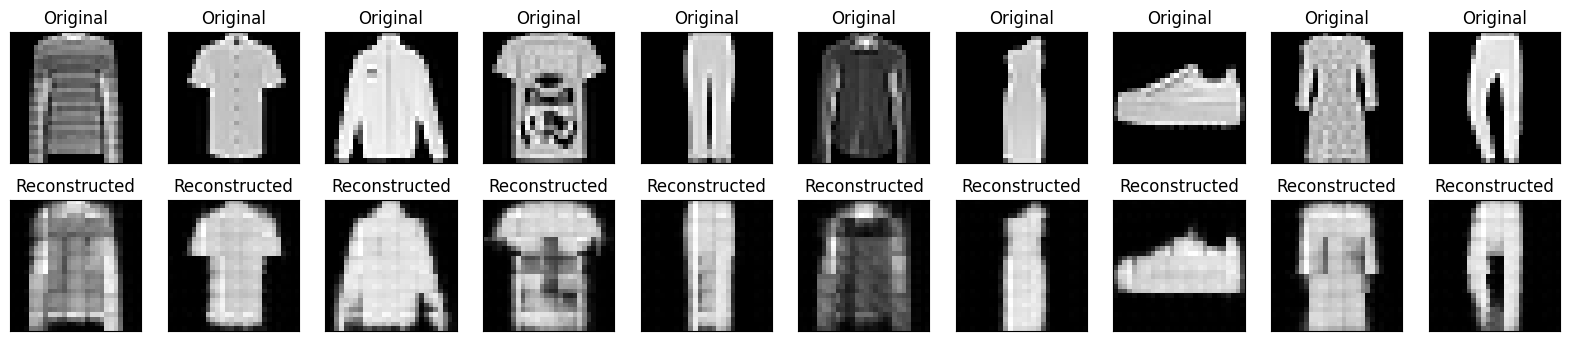

 71%|███████▏  | 15/21 [08:05<03:30, 35.16s/it]

Epoch 15 | Training Loss: 0.013
Epoch 15 | Validation Loss: 0.01342


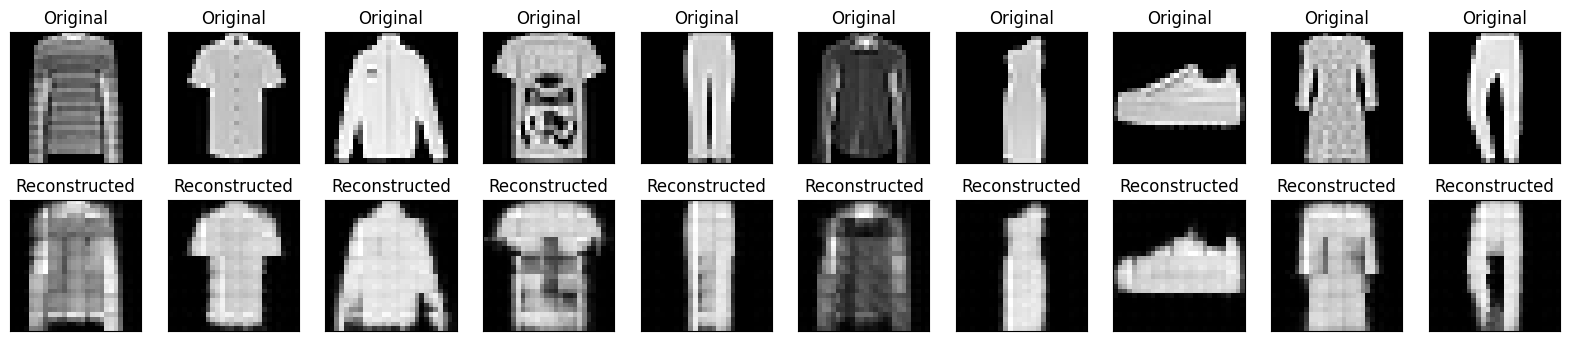

 76%|███████▌  | 16/21 [08:52<03:14, 38.81s/it]

Epoch 16 | Training Loss: 0.013
Epoch 16 | Validation Loss: 0.01325


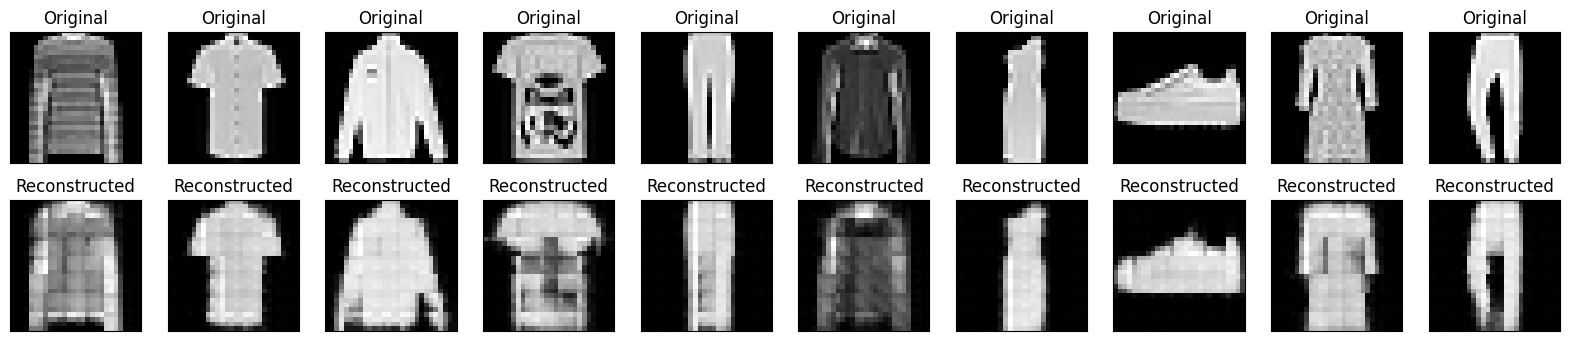

 81%|████████  | 17/21 [09:41<02:46, 41.75s/it]

Epoch 17 | Training Loss: 0.013
Epoch 17 | Validation Loss: 0.01312


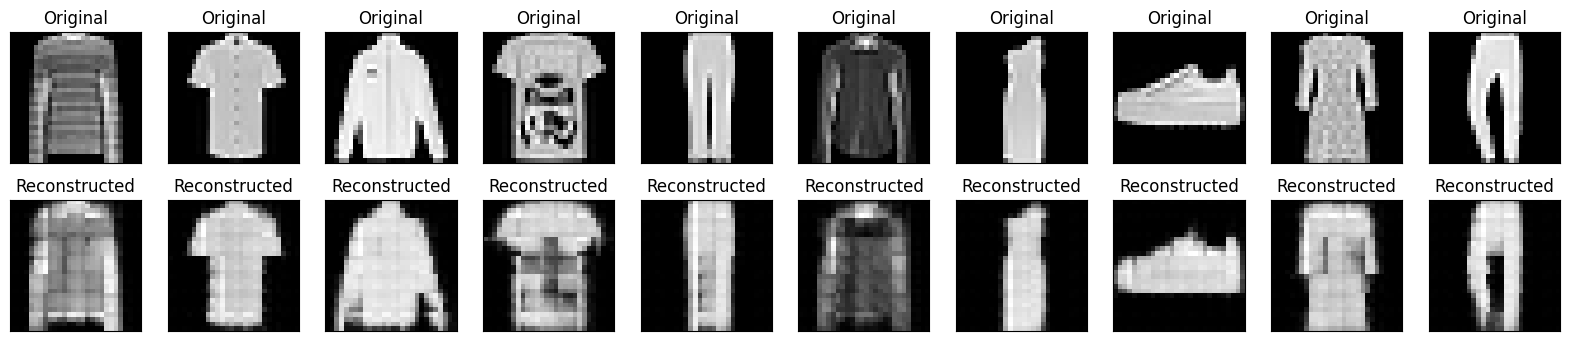

 86%|████████▌ | 18/21 [10:19<02:02, 40.68s/it]

Epoch 18 | Training Loss: 0.013
Epoch 18 | Validation Loss: 0.01300


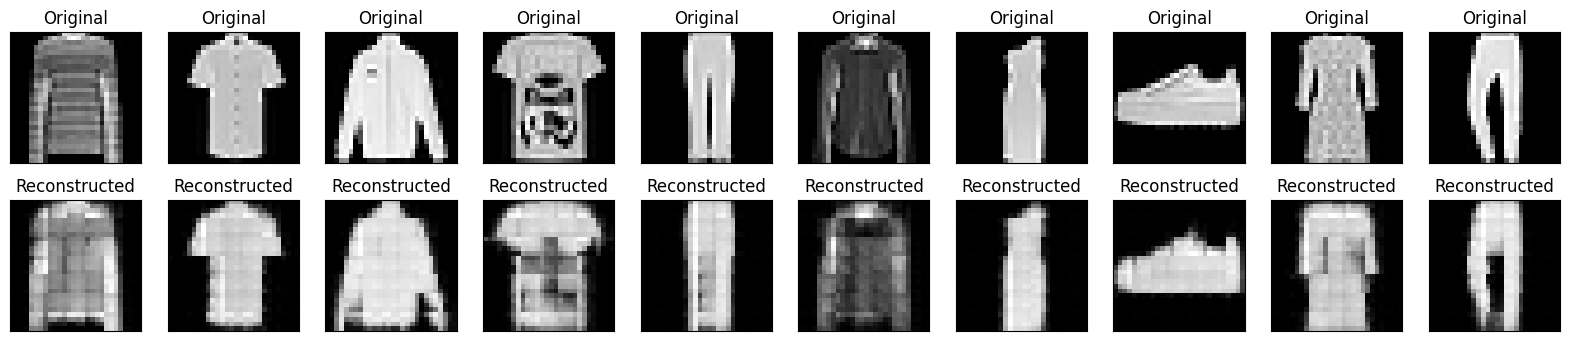

 90%|█████████ | 19/21 [10:58<01:20, 40.12s/it]

Epoch 19 | Training Loss: 0.013
Epoch 19 | Validation Loss: 0.01291


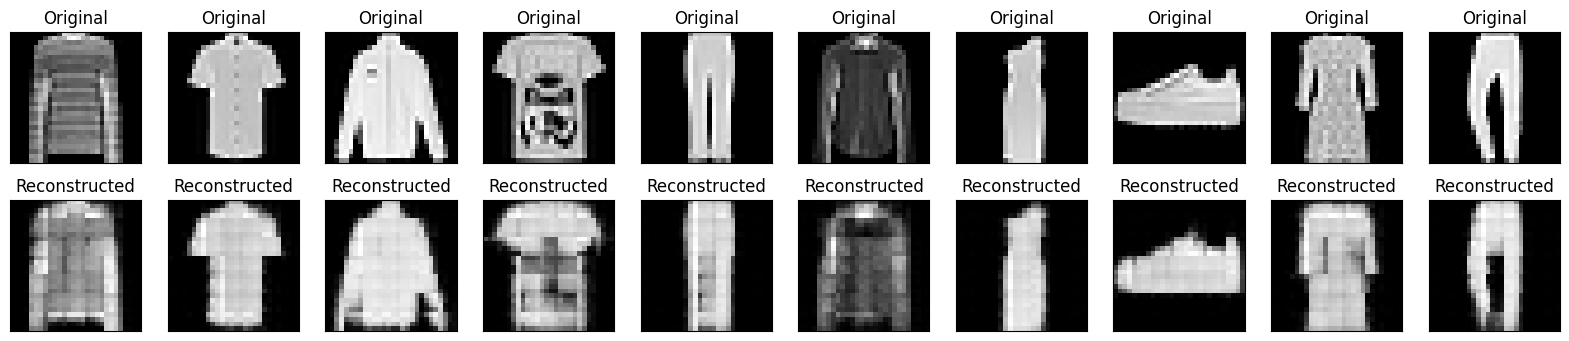

 95%|█████████▌| 20/21 [11:42<00:41, 41.30s/it]

Epoch 20 | Training Loss: 0.013
Epoch 20 | Validation Loss: 0.01280


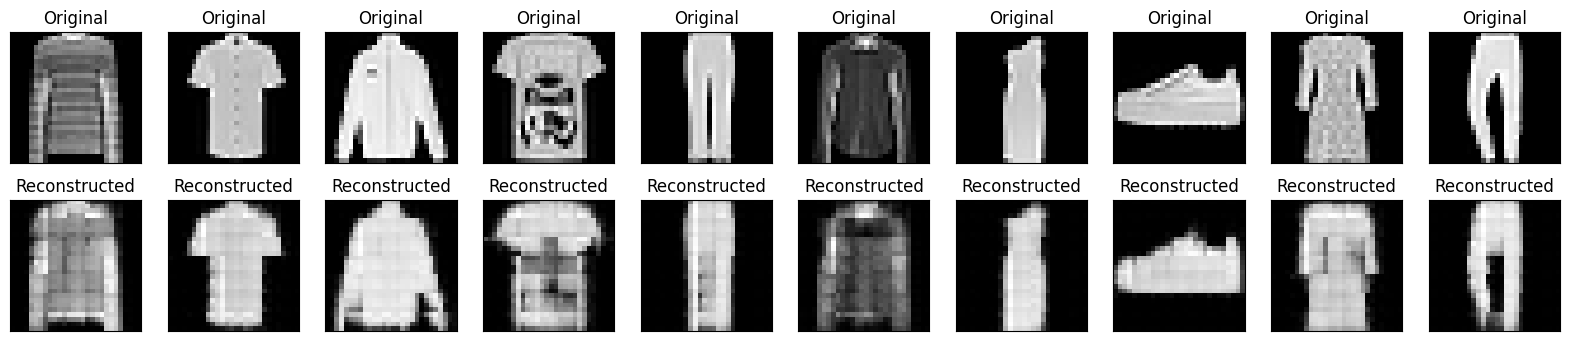

100%|██████████| 21/21 [12:18<00:00, 35.15s/it]


In [33]:
#Training Process

train_loss_list = [] # keep track of the lost function on the training and validation set
val_loss_list = []

for epoch in tqdm(range(epochs + 1)):  #tqdm to show progress bar with each epochs of training.
  if epoch > 0: #start training when epoch is 1 which is the second epoch
    model.train() # model is in training mode
    train_running_loss = 0.0

    # Iterate over every batch in the training data
    for i ,(X_train, y) in enumerate(train_dl): # nested for loop though the batches of training data - X_train: images, y: labels
      X_train = X_train.to(device)
      optimizer.zero_grad()

      reconstructed_X_train = model(X_train) #forward pass through the autoencoder

      loss = criterion(reconstructed_X_train, X_train) #comapred the reconstructed images with the original and computer the mean square error loss

      loss.backward() #compute the gradients for the model parameters

      train_running_loss += loss.item() # sum the loss

      optimizer.step() #update the model parameters

    train_loss = train_running_loss / len(train_dl) #compute the training loss for the epoch
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch} | Training Loss: {train_loss:.3f}') #print the training loss

  with torch.no_grad():
    model.eval()
    val_running_loss = 0.0

    for i, (X_val, y) in enumerate(valid_dl):
      X_val = X_val.to(device)

      reconstructed_X_val = model(X_val)

      loss = criterion(reconstructed_X_val, X_val)
      val_running_loss += loss.item()

    val_loss = val_running_loss / len(valid_dl)
    val_loss_list.append(val_loss)

  print(f'Epoch {epoch} | Validation Loss: {val_loss:.5f}')
  display_images(X_val, reconstructed_X_val, 10)

### Visualize the training and validation loss

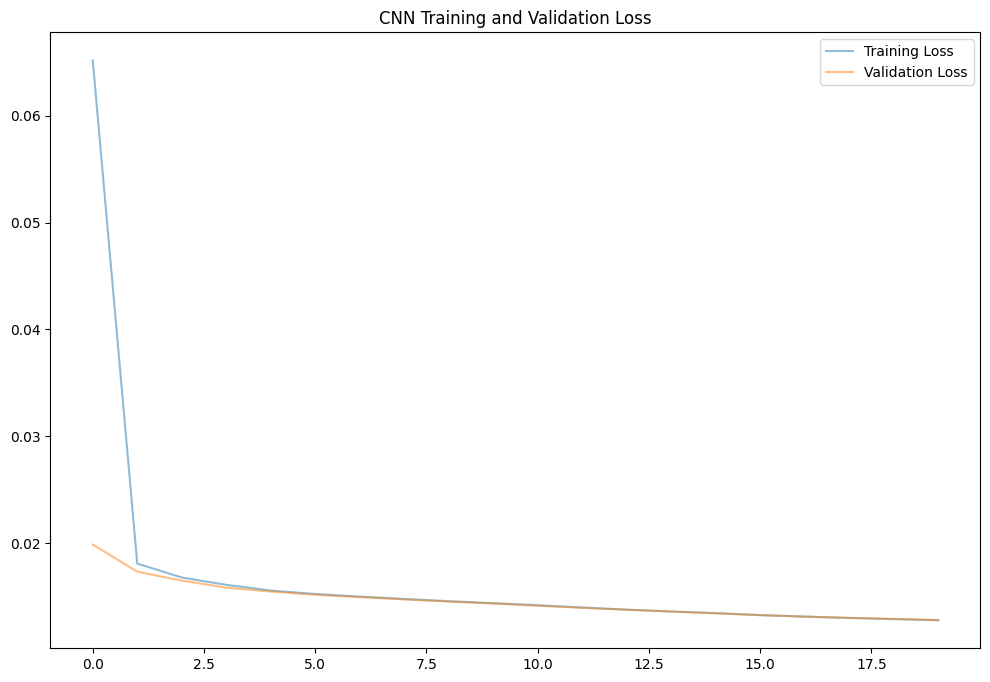

In [34]:
fig, (ax) = plt.subplots(1,1, figsize =(12,8))

ax.plot(train_loss_list, label = "Training Loss", alpha = 0.5)
ax.plot(val_loss_list[1:], label = "Validation Loss", alpha = 0.5)
ax.set_title("CNN Training and Validation Loss")
ax.legend()

# Prediction - using test data

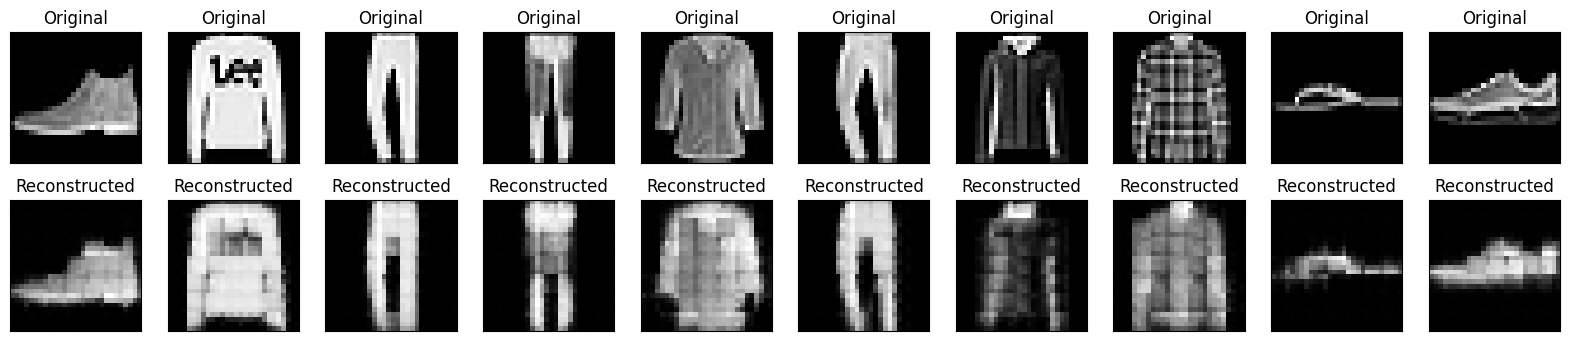

In [35]:
test_images, _ = next(iter(test_dl))
test_images = test_images.to(device)

reconstructed_test_images = model(test_images)
display_images(test_images, reconstructed_test_images, 10)

### Latent Representation of the produced by the encoder model in 2D space

- The encodings generated are in the form of feature maps.

In [36]:
train_images, train_labels = next(iter(train_dl))
train_images_encodings = model.encoder(train_images.to(device))
train_images_encodings.shape

torch.Size([128, 4, 7, 7])

Batch_size - 128
number of channels - 4 ( there are 4 : 7x7 feature maps )
height - 7
width - 7

In [37]:
train_images_encodings[0]

tensor([[[ 5.7573,  5.4199,  5.5231,  5.4600,  5.4620,  5.5572,  5.5884],
         [ 5.6043,  6.2359,  6.3999,  6.7440,  6.5092,  6.4722,  5.6309],
         [ 2.7449,  3.9130,  2.6513,  2.3781,  2.9605,  4.2594,  2.0625],
         [ 3.1520,  2.4663,  3.0639,  3.5064,  3.2091,  0.9077,  1.2509],
         [ 3.2102,  2.5596,  2.4710,  3.5140,  1.3877,  2.5832,  1.4192],
         [ 2.9228,  2.3812,  2.1538,  1.2527,  1.5277,  1.9366,  1.5781],
         [ 4.4857,  4.5378,  4.5089,  4.4163,  4.3579,  4.3670,  4.3724]],

        [[ 1.3758,  1.1602,  1.2355,  1.2067,  1.2142,  1.1777,  1.1817],
         [ 8.4488,  8.1432,  8.6252,  9.1168,  9.0492,  8.7137,  8.4140],
         [11.8236, 10.3683, 10.3500, 10.4460, 10.7662, 11.6047, 13.4036],
         [12.0710, 12.3574, 10.9374, 10.0954, 12.1355, 13.5368, 12.2527],
         [10.9858, 11.3998, 11.9551, 11.7404, 12.5093, 11.7912, 11.1822],
         [11.2180, 10.9177, 11.4863, 11.6472, 11.6340, 10.5128, 11.0472],
         [ 1.6843,  1.5590,  1.4230,

Reshape these encodings - rather than 4 feature maps each 7 x 7
is represented as a single vector

- view function will preserve the batch size
- but the encodings of each image 196 = 4*7*7. The feature map representations for each image has been flattened.

In [38]:
te = train_images_encodings.view(train_images_encodings.size(0), -1).cpu().detach().numpy()
te.shape

(128, 196)

Generate flatten encodings for all the data in our data loader.

In [39]:
def get_encoding(model, data_loader):
  encodings_list = []
  labels_list = []

  for images, labels in data_loader:  #loop over all batches of the data loader
    with torch.no_grad():
      encoding = model.encoder(images.to(device))

      #Flatten the encodings (batch_size is the first dimension at 0)
      encodings = encoding.view(encoding.size(0), -1).cpu().numpy()

      encodings_list.append(encodings)
      labels_list.extend(labels.tolist())

  # return one large tensor with the encodings for all images in the data loader
  return np.vstack(encodings_list), labels_list #np.vstack so we dont have batches of encodings


In [40]:
encodings, labels = get_encoding(model, train_dl)

len(encodings), len(labels)

(50000, 50000)

Each encoding has a dimensionality of 196, that is the flattened representation of the feature maps output by the encoder.

It is impossible for us to visualize these latent representations in a hyperspace with 196 dimensions.

In [41]:
encodings[0].shape

(196,)

This is why you need a dimensionality reduction technique to project these latent representations to 2D space.

TSNE  ( t-distributed stochastic neighbor embedding )
dimensionality reduction technique used primarily for visualizing high-dimensional data in lower dimensional space.

Manifold Learning Technique
which means its used to reduce the dimensionality of non linear data.

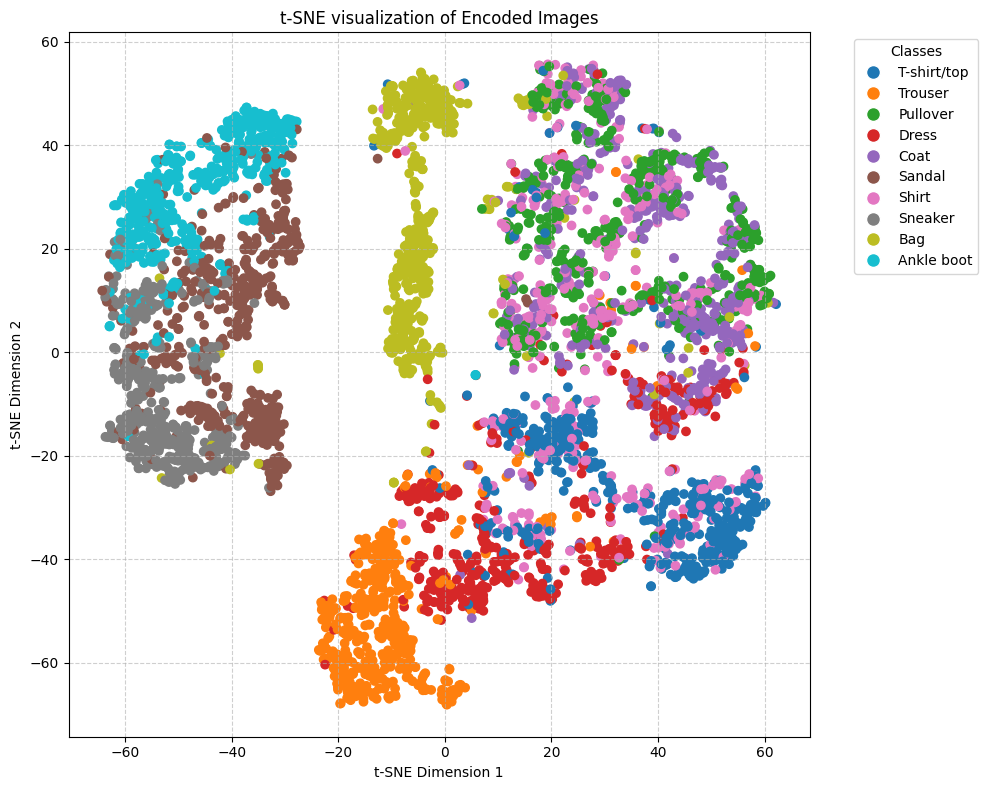

In [42]:
# Performn T-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, random_state = 42)          # instantiate the TSNE estimator ; n_components=2 means reduced to 2D
feature_maps_tsne = tsne.fit_transform(encodings[:5000])  # pass in the feature maps with reduced dimensionality

# Visualize T-SNE
plt.figure(figsize=(10, 8))
scatter = plt.scatter(feature_maps_tsne[:, 0], feature_maps_tsne[:, 1], c = labels[:5000], cmap = 'tab10')

# Get class names from the dataset
# Assuming train_data.dataset.classes is available from earlier cells
class_names = train_data.dataset.classes

# Create a legend
legend_elements = []
for i, class_name in enumerate(class_names):
    # Create a dummy scatter point for each class to use in the legend
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label=class_name,
                             markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10))

plt.legend(handles=legend_elements, title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE visualization of Encoded Images')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()